# Training Run Analysis

Report on a single training run directory produced by `train_ftr.py` / `train_d3qn.py` /
`train_icmd3qn.py` / `train_ctrac.py` — i.e. `logs/<job_name>_<job_id>/` (SLURM) or
`runs/<category>/<run_name>/` (local).

A run directory contains:
- **`attempt_N/`** — one per respawn. Crash-respawns restart the frame counter at 0 and resume the
  policy from the *last saved checkpoint* of the previous attempt, so frames collected after that
  checkpoint are lost work. Each attempt holds the metric CSVs (`train`, `env`, `rew`, `eval`,
  `eval_per_env`, `failure`, `explosion(s)`, `state`, `action`, `shock`, `torque`, …), the resolved
  `config.yaml`, and `weights/`.
- **`<job>.out` / `<job>.err`** — the SLURM stdout/stderr for the *whole* job, with every respawn
  concatenated. `Starting training (respawn #N of M)` delimits attempts, the
  `RunLogger initialized for run …_attempt_N` line maps each segment to its `attempt_N/` dir, and
  `Python script finished with exit status: X` closes it.

Section 1 is the headline: **total training time and total frames across all attempts**.

In [176]:
import re
import json
import warnings
from datetime import datetime, timedelta
from pathlib import Path

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mtick

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "font.size":        11,
    "axes.titlesize":   12,
    "axes.labelsize":   11,
    "xtick.labelsize":  9,
    "ytick.labelsize":  9,
    "legend.fontsize":  9,
    "figure.titlesize": 14,
    "axes.grid":        True,
    "grid.linestyle":   "--",
    "grid.linewidth":   0.3,
    "grid.color":       "gray",
})

# Workspace root — notebook lives at <WS_ROOT>/notebooks/training_analysis.ipynb
try:
    WS_ROOT = Path(__vsc_ipynb_file__).resolve().parent.parent
except NameError:
    WS_ROOT = Path.cwd().parent  # fallback when cwd is the notebooks/ dir

# ── CONFIG ────────────────────────────────────────────────────────────────────
# The run directory to report on. Relative paths resolve against WS_ROOT.
RUN_DIR = "logs/train_atd3qn_11396783"

# Save figures to notebooks/images/ alongside displaying them.
SAVE_FIGS = False
IMAGES_DIR = WS_ROOT / "notebooks/images"

# Palette used to colour attempts consistently across every figure.
ATTEMPT_PALETTE = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3",
                   "#937860", "#DA8BC3", "#8C8C8C", "#CCB974", "#64B5CD"]

RUN_PATH = Path(RUN_DIR)
if not RUN_PATH.is_absolute():
    RUN_PATH = WS_ROOT / RUN_PATH
RUN_PATH = RUN_PATH.resolve()
assert RUN_PATH.is_dir(), f"run dir not found: {RUN_PATH}"

def _savefig(name):
    if SAVE_FIGS:
        IMAGES_DIR.mkdir(parents=True, exist_ok=True)
        plt.savefig(IMAGES_DIR / f"{RUN_PATH.name}_{name}.svg", format="svg", bbox_inches="tight")

print(f"Run directory : {RUN_PATH}")

Run directory : /home/robot/workspaces/MARV_RL/logs/train_atd3qn_11396783


## 1  Parse the run

Two independent sources are merged per attempt:

- the **CSV metrics** in `attempt_N/` — what the trainer measured (frames, reward, losses, eval);
- the **SLURM `.out` log** — when each attempt started and stopped, and *why* it stopped.

The `.out` is split on `Starting training (respawn #N …)`; each segment is bound to an `attempt_N`
dir by its `RunLogger initialized …` line (respawn index and attempt index can diverge — an attempt
that died before `RunLogger` ran leaves no directory). Timestamps come from the Python logger lines
(`YYYY-MM-DD HH:MM:SS,mmm`), which share one clock; the Isaac/carb `[Nms]` lines are on a different
timezone offset and are ignored. When there is no `.out` at all (local runs), attempt durations fall
back to the mtime span of the attempt's CSVs.

In [177]:
# ── SLURM log parsing ─────────────────────────────────────────────────────────
#  Two banner shapes exist: the legacy "(respawn #N of M)" and the current
#  "(respawn #N — <done>/<budget> frames done, <left> to go)" that slurm/train_*.sbatch print
#  now that respawns are bounded by the frame budget instead of a count. Matching only the first
#  collapses a whole job into one segment, so every attempt but the first loses its log times.
_RE_SEG_START   = re.compile(r"^Starting training \(respawn #(\d+)(?: of (\d+))?", re.MULTILINE)
_RE_RUNLOGGER   = re.compile(r"RunLogger initialized for run \S*?attempt_(\d+) at (\S+)")
_RE_EXIT        = re.compile(r"(?:Python script|Training) finished with exit (?:status|code):?\s*(\d+)")
_RE_PY_TS       = re.compile(r"^(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}),\d{3}", re.MULTILINE)
_RE_CARB_TS     = re.compile(r"^(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}) \[[\d,]+ms\]", re.MULTILINE)
_RE_FAIL        = re.compile(r"Training failed:\s*(.+)")
_RE_TRAIN_DONE  = re.compile(r"Training finished with exit (?:code|status):?\s*0|Job finished\.|Training complete", re.IGNORECASE)
_RE_MAX_RESPAWN = re.compile(r"Max respawns \((\d+)\) reached")
_RE_CANCELLED   = re.compile(r"CANCELLED AT .*DUE TO TIME LIMIT")
_RE_SLURM_KILL  = re.compile(r"CANCELLED AT")
_RE_CUDA        = re.compile(r"CUDA error|illegal memory access|CUDA.*out of memory", re.IGNORECASE)
_RE_OOM         = re.compile(r"out of memory|Killed process|oom-kill", re.IGNORECASE)
_RE_EXC_TYPE    = re.compile(r"^([A-Za-z][A-Za-z0-9_.]*(?:Error|Exception|Interrupt|Killed))\b", re.MULTILINE)
_RE_NODE        = re.compile(r"Running on node:\s*(\S+)")
_RE_GPU_NAME    = re.compile(r"\|\s+\d+\s+(NVIDIA [A-Za-z0-9\- ]+?)\s+(?:On|Off)\s+\|")
_RE_TQDM        = re.compile(r"(\d+)/(\d+) \[(?:(\d+):)?(\d+):(\d+)<")


def _find_job_logs(run_path):
    out = sorted(run_path.glob("*.out"))
    err = sorted(run_path.glob("*.err"))
    return (out[0] if out else None), (err[0] if err else None)


def _py_ts(text):
    return [datetime.strptime(m, "%Y-%m-%d %H:%M:%S") for m in _RE_PY_TS.findall(text)]


def _carb_offset(chunks):
    #  Isaac/carb lines carry their own clock, a timezone shift away from the Python logger's. The
    #  two cannot be aligned by file order: carb output is block-buffered, so an attempt's boot
    #  warnings may be flushed hours later, *after* the Python lines they physically preceded (seen
    #  in train_atd3qn_11396782 — that inversion made the old chronology-intersection estimate
    #  infeasible, and falling back to its lower bound put every attempt's end ~5 h past its start).
    #  Each respawn chunk instead begins with an Isaac boot a minute or two before the trainer's
    #  first Python line, so per chunk (first python ts − first carb ts) is the shift plus the boot
    #  time. The median over chunks rejects a chunk that died before the trainer logged anything,
    #  and rounding to a quarter hour (timezone offsets are) absorbs the boot time.
    deltas = []
    for chunk in chunks:
        py, cb = _RE_PY_TS.findall(chunk), _RE_CARB_TS.findall(chunk)
        if not py or not cb:
            continue
        t_py = min(datetime.strptime(m, "%Y-%m-%d %H:%M:%S") for m in py)
        t_cb = min(datetime.strptime(m, "%Y-%m-%d %H:%M:%S") for m in cb)
        deltas.append((t_py - t_cb).total_seconds())
    if not deltas:
        return timedelta(0)
    return timedelta(seconds=round(float(np.median(deltas)) / 900) * 900)


def _all_ts(text, carb_off):
    #  Every timestamp in the chunk on one clock: Python-logger lines plus carb lines shifted onto it.
    ts = _py_ts(text)
    ts += [datetime.strptime(m, "%Y-%m-%d %H:%M:%S") + carb_off for m in _RE_CARB_TS.findall(text)]
    return sorted(ts)


def _classify(exit_status, fail_msg, text, is_last, job_cancelled):
    if _RE_CUDA.search(fail_msg or "") or (exit_status == 75 and _RE_CUDA.search(text)):
        return "crash_cuda"
    if _RE_OOM.search(fail_msg or ""):
        return "crash_oom"
    if exit_status == 0:
        return "success" if _RE_TRAIN_DONE.search(text) or not fail_msg else "exit0_with_error"
    if fail_msg:
        return "crash_python"
    if exit_status == 75:
        return "crash_75_cuda_or_wandb"
    if exit_status == 255:
        return "crash_255_container_killed"
    if exit_status is not None:
        return f"crash_exit_{exit_status}"
    if job_cancelled:
        return "timeout" if _RE_CANCELLED.search(text) else "cancelled"
    return "running_or_killed" if is_last else "killed_no_exit"


def parse_job_log(out_path):
    #  -> (list of per-segment dicts, job-level dict)
    if out_path is None:
        return [], {}
    text = out_path.read_text(errors="replace")
    job = {
        "node":       (_RE_NODE.search(text).group(1) if _RE_NODE.search(text) else None),
        "gpu":        (_RE_GPU_NAME.search(text).group(1).strip() if _RE_GPU_NAME.search(text) else None),
        "max_respawns": (int(_RE_MAX_RESPAWN.search(text).group(1)) if _RE_MAX_RESPAWN.search(text) else None),
        "cancelled":  bool(_RE_SLURM_KILL.search(text)),
    }
    starts = [(m.start(), int(m.group(1)), int(m.group(2)) if m.group(2) else None)
              for m in _RE_SEG_START.finditer(text)]
    if not starts:
        starts = [(0, 0, None)]
    bounds = [s[0] for s in starts] + [len(text)]
    chunks = [text[bounds[i]:bounds[i + 1]] for i in range(len(starts))]

    carb_off = _carb_offset(chunks)
    job["carb_offset_h"] = carb_off.total_seconds() / 3600

    segs = []
    for i, (_, respawn, n_respawns) in enumerate(starts):
        chunk = chunks[i]
        ts = _all_ts(chunk, carb_off)
        m_rl   = _RE_RUNLOGGER.search(chunk)
        m_exit = _RE_EXIT.search(chunk)
        m_fail = _RE_FAIL.search(chunk)
        exit_status = int(m_exit.group(1)) if m_exit else None
        fail_msg = m_fail.group(1).strip() if m_fail else None
        segs.append({
            "respawn":      respawn,
            "n_respawns":   n_respawns,
            "attempt":      int(m_rl.group(1)) if m_rl else None,
            "log_start":    ts[0] if ts else None,
            "log_end":      ts[-1] if ts else None,
            "exit_status":  exit_status,
            "fail_msg":     fail_msg,
            "status":       _classify(exit_status, fail_msg, chunk,
                                      i == len(starts) - 1, job["cancelled"]),
            "exceptions":   ", ".join(sorted(set(_RE_EXC_TYPE.findall(chunk)))) or None,
        })
    # An attempt's timestamps only start once the trainer's Python logger runs, i.e. after Isaac Sim
    # has booted. The gap to the previous attempt's last line is the crash-cleanup + startup cost and
    # is kept separate rather than folded into the attempt's duration.
    for i, s in enumerate(segs):
        prev_end = segs[i - 1]["log_end"] if i else None
        s["seg_start"] = s["log_start"]
        s["gap_before"] = ((s["log_start"] - prev_end).total_seconds() / 3600
                           if (prev_end and s["log_start"]) else np.nan)
    all_ts = _all_ts(text, carb_off)
    job["first_ts"] = all_ts[0] if all_ts else None
    job["last_ts"] = all_ts[-1] if all_ts else None
    return segs, job


OUT_PATH, ERR_PATH = _find_job_logs(RUN_PATH)
SEGMENTS, JOB_INFO = parse_job_log(OUT_PATH)
print(f".out : {OUT_PATH.name if OUT_PATH else '— none (local run)'}")
print(f".err : {ERR_PATH.name if ERR_PATH else '— none'}")
print(f"job  : node={JOB_INFO.get('node')}  gpu={JOB_INFO.get('gpu')}  "
      f"segments={len(SEGMENTS)}  max_respawns={JOB_INFO.get('max_respawns')}")

.out : train_atd3qn_11396783.out
.err : train_atd3qn_11396783.err
job  : node=g12  gpu=NVIDIA A100-SXM4-40GB  segments=2  max_respawns=None


In [178]:
# ── Attempt discovery + per-attempt facts ─────────────────────────────────────
CSV_GROUPS = ["train", "env", "rew", "eval", "eval_per_env", "failure", "explosion",
              "explosions", "state", "action", "shock", "torque", "clearance",
              "grad_contrib", "var_decomp", "observations"]

def _attempt_dirs(run_path):
    ds = [p for p in run_path.iterdir() if p.is_dir() and re.fullmatch(r"attempt_\d+", p.name)]
    return sorted(ds, key=lambda p: int(p.name.split("_")[1]))

def _mtime_span(d):
    ts = [f.stat().st_mtime for f in d.glob("*.csv")]
    ts += [f.stat().st_mtime for f in (d / "weights").glob("*.pth")] if (d / "weights").is_dir() else []
    if not ts:
        return None, None
    return datetime.fromtimestamp(min(ts)), datetime.fromtimestamp(max(ts))

def _checkpoint_frames(d):
    steps = []
    for p in (d / "weights").glob("policy_step_*.pth"):
        m = re.search(r"policy_step_(\d+)\.pth", p.name)
        if m:
            steps.append(int(m.group(1)))
    return sorted(steps)

def _read_group(d, name):
    p = d / f"{name}.csv"
    if not p.exists():
        return None
    try:
        df = pd.read_csv(p)
    except (OSError, ValueError, pd.errors.EmptyDataError):
        return None
    return df if len(df) else None


ATTEMPT_DIRS = _attempt_dirs(RUN_PATH)
assert ATTEMPT_DIRS, f"no attempt_* directories under {RUN_PATH}"
seg_by_attempt = {s["attempt"]: s for s in SEGMENTS if s["attempt"] is not None}

rows = []
RAW = {}   # {attempt_idx: {group: DataFrame}}
for d in ATTEMPT_DIRS:
    idx = int(d.name.split("_")[1])
    RAW[idx] = {g: df for g in CSV_GROUPS if (df := _read_group(d, g)) is not None}
    tr  = RAW[idx].get("train")
    ev  = RAW[idx].get("eval")
    ckpts = _checkpoint_frames(d)
    seg = seg_by_attempt.get(idx, {})

    mt_first, mt_last = _mtime_span(d)
    frames = int(tr["collected_frames"].max()) if tr is not None else 0
    rows.append({
        "attempt":        idx,
        "dir":            d,
        "log_start":      seg.get("seg_start"),
        "log_end":        seg.get("log_end"),
        "mtime_first":    mt_first,
        "mtime_last":     mt_last,
        "frames":         frames,
        "iters":          len(tr) if tr is not None else 0,
        "ckpt_frames":    max(ckpts) if ckpts else 0,
        "n_ckpts":        len(ckpts),
        "n_evals":        len(ev) if ev is not None else 0,
        "respawn":        seg.get("respawn"),
        "exit_status":    seg.get("exit_status"),
        "status":         seg.get("status", "unknown"),
        "fail_msg":       seg.get("fail_msg"),
        "exceptions":     seg.get("exceptions"),
        "final_reward":   float(tr["train/mean_reward"].iloc[-1]) if tr is not None and "train/mean_reward" in tr else np.nan,
        "final_success":  float(RAW[idx]["env"]["env/success_rate"].iloc[-1])
                          if "env" in RAW[idx] and "env/success_rate" in RAW[idx]["env"] else np.nan,
        "best_eval_success": float(ev["eval/success_rate"].max())
                          if ev is not None and "eval/success_rate" in ev else np.nan,
    })

attempts = pd.DataFrame(rows).sort_values("attempt").reset_index(drop=True)

# ── When did each attempt start and stop? ────────────────────────────────────
# The job log gives the truth for the start. For the end it is only reliable when the attempt died
# noisily; a long attempt whose progress went to the tqdm bar in .err can leave the .out silent for
# hours. The metric CSVs are rewritten at every log interval, so their newest mtime marks the last
# training activity — used to extend the end whenever it is later than the log and still lands before
# the next attempt started (i.e. the mtimes were preserved through any rsync).
_next_start = attempts["log_start"].shift(-1)
starts, ends, srcs = [], [], []
# NB: a missing log timestamp becomes NaT once pandas builds the column, and `pd.NaT` is truthy —
# `log_start or mtime_first` would keep the NaT and silently drop the attempt from every time-based
# figure. The fallback therefore has to be selected with an explicit notna() test.
for i, r in attempts.iterrows():
    has_log = pd.notna(r["log_start"])
    start = r["log_start"] if has_log else r["mtime_first"]
    end   = r["log_end"]   if pd.notna(r["log_end"]) else r["mtime_last"]
    src   = "slurm_log" if has_log else "file_mtime"
    mt_last, nxt = r["mtime_last"], _next_start.iloc[i]
    if (pd.notna(mt_last) and pd.notna(end) and pd.notna(start)
            and mt_last > end and (pd.isna(nxt) or mt_last <= nxt)):
        end, src = mt_last, src + "+mtime"
    starts.append(start); ends.append(end); srcs.append(src)
attempts["start"], attempts["end"], attempts["time_source"] = starts, ends, srcs
attempts["hours"] = [(e - s).total_seconds() / 3600 if (pd.notna(s) and pd.notna(e)) else np.nan
                     for s, e in zip(attempts["start"], attempts["end"])]
attempts["gap_before_h"] = [np.nan] + [
    (attempts["start"].iloc[i] - attempts["end"].iloc[i - 1]).total_seconds() / 3600
    if (pd.notna(attempts["start"].iloc[i]) and pd.notna(attempts["end"].iloc[i - 1])) else np.nan
    for i in range(1, len(attempts))]

# ── Absolute frame axis across attempts ──────────────────────────────────────
# An attempt that could not restore `training_state.pth` restarts `collected_frames` at 0, so its
# rows have to be offset by everything that came before. When the restore works, the counter carries
# on from the previous attempt and the numbers are already absolute. Both happen in practice (the
# restore was broken for a long time), sometimes within one job — so decide per attempt: a first row
# already past the previous attempt's end means the counter continued.
ITER_SIZE = int(np.median([d for a in RAW.values() if (t := a.get("train")) is not None and len(t) > 1
                           for d in np.diff(t["collected_frames"])] or [1]))

prev_end, offsets, spans, kept, ends, starts = 0, [], [], [], [], []
for _, r in attempts.iterrows():
    tr = RAW[r["attempt"]].get("train")
    lo = int(tr["collected_frames"].min()) if tr is not None else 0
    hi = int(tr["collected_frames"].max()) if tr is not None else 0
    # A restarted counter logs its first row at exactly one iteration; a continued one starts at the
    # checkpoint it resumed from plus one iteration, which is well past that. (It is *not* enough to
    # compare against the previous attempt's last row — the crash discarded the frames after that
    # attempt's last checkpoint, so a resumed counter starts below where the previous one stopped.)
    continued = lo > 1.5 * ITER_SIZE
    off = 0 if continued else prev_end
    start = (lo - ITER_SIZE) if continued else prev_end   # absolute frame count it resumed from
    end = off + hi
    # Frames the next attempt inherited: it resumes from the last checkpoint, so anything collected
    # after that checkpoint was thrown away by the crash. `off + ckpt` is correct under both
    # conventions (off is 0 exactly when the checkpoint name is already absolute), and the checkpoint
    # counter can sit one save interval past the last logged CSV row, hence the clamp.
    ckpt_abs = (off + int(r["ckpt_frames"])) if r["ckpt_frames"] else start
    compute = max(end - start, 0)
    offsets.append(off)
    starts.append(start)
    ends.append(end)
    spans.append(compute)
    kept.append(min(max(ckpt_abs - start, 0), compute))
    prev_end = end

attempts["frame_offset"] = offsets
attempts["cum_frames"]   = ends           # absolute frame count at the end of the attempt
attempts["frames"]       = spans          # frames this attempt collected on its own
attempts["kept_frames"]  = kept
attempts.loc[attempts.index[-1], "kept_frames"] = attempts["frames"].iloc[-1]
attempts["lost_frames"]  = (attempts["frames"] - attempts["kept_frames"]).clip(lower=0)
attempts["frames_per_s"] = attempts["frames"] / (attempts["hours"] * 3600)
attempts["frame_start"]  = starts          # absolute frames it resumed from
attempts["counter"]      = np.where(np.array(offsets) == 0, "continued", "restarted")
attempts.loc[attempts.index[0], "counter"] = "initial"

ATTEMPT_COLOR = {a: ATTEMPT_PALETTE[i % len(ATTEMPT_PALETTE)]
                 for i, a in enumerate(attempts["attempt"])}

# Respawns that died before RunLogger created their directory leave a log segment with no CSVs — their
# time is in the job span but cannot be attributed to an attempt.
_orphans = [s for s in SEGMENTS if s["attempt"] is None or s["attempt"] not in set(attempts["attempt"])]
if _orphans:
    print(f"[note] {len(_orphans)} log segment(s) have no attempt_N directory "
          f"(respawn #{', #'.join(str(s['respawn']) for s in _orphans)}) — "
          f"they died before RunLogger ran and are excluded from the per-attempt totals.\n")

display(attempts[["attempt", "start", "end", "hours", "gap_before_h", "frames", "iters", "n_ckpts",
                  "kept_frames", "lost_frames", "frames_per_s", "counter", "status", "time_source"]]
        .style.format({"hours": "{:.2f}", "gap_before_h": "{:.2f}", "frames": "{:,.0f}",
                       "kept_frames": "{:,.0f}", "lost_frames": "{:,.0f}", "frames_per_s": "{:.0f}"}))

,attempt,start,end,hours,gap_before_h,frames,iters,n_ckpts,kept_frames,lost_frames,frames_per_s,counter,status,time_source
0,0,2026-08-24 06:50:14,2026-08-24 15:32:18,8.70,nan,"22,282,240",170,22,"22,151,168","131,072",711,initial,crash_cuda,slurm_log
1,1,2026-08-24 15:32:31,2026-08-25 06:46:55,15.24,0.00,"38,797,312",296,38,"38,797,312",0,707,continued,running_or_killed,slurm_log+mtime


In [179]:
# ── Resolved training config (OmegaConf resolvers evaluated where trivial) ────
_RE_RESOLVER = re.compile(r"\$\{(mul|add|intdiv|sub):([^{}]*)\}")

def _resolve_scalar(val, depth=6):
    #  ${mul:a,b} / ${intdiv:a,b} / ${add:a,b} — only the arithmetic ones, only when args are numeric
    if not isinstance(val, str):
        return val
    s = val
    for _ in range(depth):
        m = _RE_RESOLVER.search(s)
        if not m:
            break
        try:
            args = [float(a) for a in m.group(2).split(",")]
        except ValueError:
            break
        op = m.group(1)
        out = (args[0] * args[1] if op == "mul" else
               args[0] + args[1] if op == "add" else
               args[0] - args[1] if op == "sub" else
               args[0] // args[1])
        s = s[:m.start()] + str(int(out)) + s[m.end():]
    try:
        return int(s)
    except ValueError:
        return val

CFG_PATH = ATTEMPT_DIRS[0] / "config.yaml"
CFG = yaml.safe_load(CFG_PATH.read_text()) if CFG_PATH.exists() else {}

TARGET_FRAMES = _resolve_scalar(CFG.get("total_frames"))
TARGET_FRAMES = TARGET_FRAMES if isinstance(TARGET_FRAMES, int) else None

_KEYS = ["name", "task", "terrain", "seed", "num_robots", "total_frames", "time_steps_per_batch",
         "epochs_per_batch", "frames_per_sub_batch", "eval_and_save_every", "eval_repeats",
         "max_grad_norm", "optimizer", "scheduler", "policy", "engine"]
cfg_rows = []
for k in _KEYS:
    if k not in CFG:
        continue
    v = CFG[k]
    if isinstance(v, dict):
        v = v.get("_target_") or v.get("cls") or f"<{len(v)} keys>"
    cfg_rows.append({"key": k, "value": str(_resolve_scalar(v))[:110]})
mod = (CFG.get("env_cfg_overrides") or {}).get("module_name")
if mod:
    cfg_rows.append({"key": "module_name", "value": mod})

print(f"config: {CFG_PATH.relative_to(RUN_PATH)}")
display(pd.DataFrame(cfg_rows).set_index("key"))
if CFG.get("comment"):
    print("\ncomment:", " ".join(str(CFG["comment"]).split())[:600])

config: attempt_0/config.yaml


,value
key,
name,atd3qn_marv_flipperonly
task,Ftr-Crossing-Direct-v0
terrain,pan_symmetric
seed,42
num_robots,1024
total_frames,62914560
time_steps_per_batch,128
eval_and_save_every,8
eval_repeats,2



comment: AT-D3QN, MARV-adapted, but with R_contact REMOVED and R_flipper boosted 3x instead. Tests whether flipper-angle shaping alone can do the job R_contact currently does -- keeping the robot down on its tracks rather than balanced on the flipper tips. This arm is closer to AT-D3QN's published reward than marv_config_atd3qn.yaml (that paper defines no R_contact at all); the deviation here is kappa_flipper, not the term set. AT-D3QN (Pan et al. 2023) flipper policy, reusing marv_asym_limits.yaml's robot/terrain/reward parameters. Front/rear flipper pairs only (2-DOF, 9-action discrete space) — requi


## 2  Headline — total training time and total frames

`Total training time` is the wall clock actually spent inside the attempts (from the first
trainer log line of an attempt to its last), summed. `Job span` is first-to-last across the whole
job and additionally covers Isaac Sim startup and crash/respawn overhead, so
`job span − training time` is the cost of the respawn cycle.

`Total frames` is every frame collected across all attempts — the compute spent. `Kept` counts
only the frames that survived into the next attempt's resume checkpoint; `lost` is what each crash
discarded between the last checkpoint and the crash.

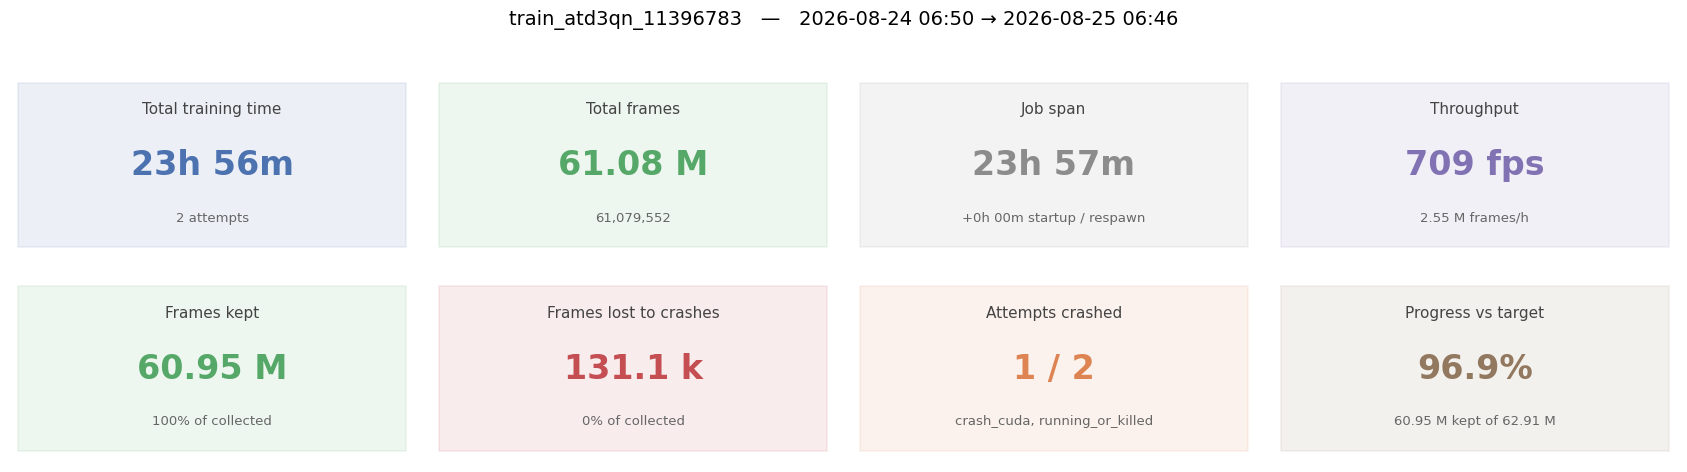

Total training time across all attempts : 23.94 h  (23h 56m)
Total frames across all attempts        : 61,079,552
  kept (resumed by next attempt)        : 60,948,480
  lost between last ckpt and crash      : 131,072
Job span (incl. startup + respawns)     : 23.94 h
Mean throughput                         : 709 frames/s


In [180]:
# ── Figure 1a: headline tiles ─────────────────────────────────────────────────
total_hours   = attempts["hours"].sum(skipna=True)
# Job span spans the whole .out (so Isaac startup before the first attempt counts too), falling back
# to the attempt extent when there is no job log.
job_start     = min([t for t in [JOB_INFO.get("first_ts"), attempts["start"].dropna().min()] if t is not None], default=None)
job_end       = max([t for t in [JOB_INFO.get("last_ts"),  attempts["end"].dropna().max()]   if t is not None], default=None)
job_span_h    = (job_end - job_start).total_seconds() / 3600 if (job_start is not None and job_end is not None) else np.nan
overhead_h    = job_span_h - total_hours
total_frames  = int(attempts["frames"].sum())
kept_frames   = int(attempts["kept_frames"].sum())
lost_frames   = int(attempts["lost_frames"].sum())
mean_fps      = total_frames / (total_hours * 3600) if total_hours else np.nan
n_crash       = int((~attempts["status"].isin(["success", "running_or_killed"])).sum())

def _fmt_h(h):
    if not np.isfinite(h):
        return "n/a"
    return f"{int(h)}h {int(round((h - int(h)) * 60)):02d}m"

def _fmt_frames(f):
    return f"{f/1e6:.2f} M" if f >= 1e6 else f"{f/1e3:.1f} k"

tiles = [
    ("Total training time", _fmt_h(total_hours),  f"{len(attempts)} attempts",                          "#4C72B0"),
    ("Total frames",        _fmt_frames(total_frames), f"{total_frames:,}",                             "#55A868"),
    ("Job span",            _fmt_h(job_span_h),   f"+{_fmt_h(max(overhead_h, 0))} startup / respawn",   "#8C8C8C"),
    ("Throughput",          f"{mean_fps:,.0f} fps" if np.isfinite(mean_fps) else "n/a",
                            f"{total_frames/max(total_hours,1e-9)/1e6:.2f} M frames/h",                 "#8172B3"),
    ("Frames kept",         _fmt_frames(kept_frames),
                            f"{100*kept_frames/max(total_frames,1):.0f}% of collected",                 "#55A868"),
    ("Frames lost to crashes", _fmt_frames(lost_frames),
                            f"{100*lost_frames/max(total_frames,1):.0f}% of collected",                 "#C44E52"),
    ("Attempts crashed",    f"{n_crash} / {len(attempts)}",
                            ", ".join(sorted(set(attempts.loc[attempts['status'] != 'success', 'status'])))[:40] or "—", "#DD8452"),
    # Progress against the config's frame budget is what survived into the current policy, not what
    # the last attempt happened to collect: respawn_common.sh sizes the remaining budget from the
    # `policy_step_<frames>.pth` checkpoints, i.e. the same kept frames, and on a run whose counter
    # restarts per attempt the last attempt's own count is a fraction of the real progress.
    ("Progress vs target",
     f"{100*kept_frames/TARGET_FRAMES:.1f}%" if TARGET_FRAMES else "n/a",
     f"{_fmt_frames(kept_frames)} kept of {_fmt_frames(TARGET_FRAMES)}" if TARGET_FRAMES else "no total_frames in config",
     "#937860"),
]

fig, axes = plt.subplots(2, 4, figsize=(17, 4.6))
for ax, (title, big, sub, color) in zip(axes.ravel(), tiles):
    ax.axis("off")
    ax.set_facecolor("none")
    ax.add_patch(plt.Rectangle((0.02, 0.06), 0.96, 0.88, transform=ax.transAxes,
                               facecolor=color, alpha=0.10, edgecolor=color, linewidth=1.2))
    ax.text(0.5, 0.80, title, ha="center", va="center", transform=ax.transAxes,
            fontsize=11, color="#444")
    ax.text(0.5, 0.50, big, ha="center", va="center", transform=ax.transAxes,
            fontsize=24, fontweight="bold", color=color)
    ax.text(0.5, 0.22, sub, ha="center", va="center", transform=ax.transAxes,
            fontsize=9.5, color="#666")
fig.suptitle(f"{RUN_PATH.name}   —   {job_start:%Y-%m-%d %H:%M} → {job_end:%Y-%m-%d %H:%M}"
             if job_start is not None else RUN_PATH.name, y=1.02)
plt.tight_layout()
_savefig("headline")
plt.show()

print(f"Total training time across all attempts : {total_hours:.2f} h  ({_fmt_h(total_hours)})")
print(f"Total frames across all attempts        : {total_frames:,}")
print(f"  kept (resumed by next attempt)        : {kept_frames:,}")
print(f"  lost between last ckpt and crash      : {lost_frames:,}")
print(f"Job span (incl. startup + respawns)     : {job_span_h:.2f} h")
print(f"Mean throughput                         : {mean_fps:,.0f} frames/s")

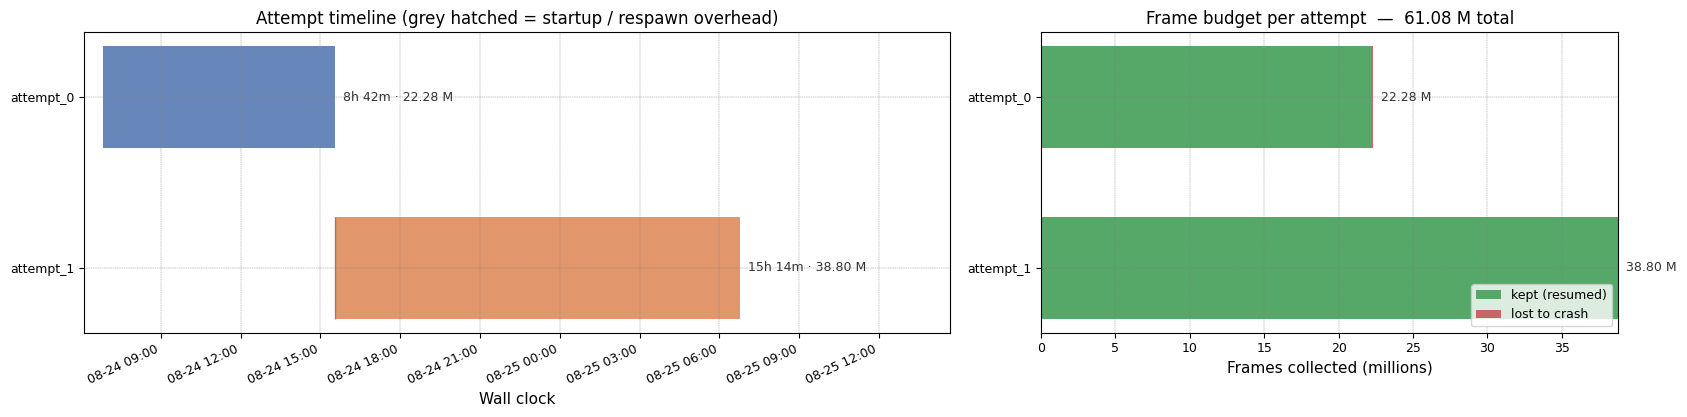

In [181]:
# ── Figure 1b: attempt timeline + frame budget ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(17, 0.55 * len(attempts) + 3.2),
                         gridspec_kw={"width_ratios": [1.5, 1]})

# — Gantt of attempts on wall-clock time
ax = axes[0]
has_time = attempts["start"].notna() & attempts["end"].notna()
for _, r in attempts[has_time].iterrows():
    # plotted in matplotlib date numbers so bar widths and datetimes cannot disagree on units
    x0, x1 = mdates.date2num(r["start"]), mdates.date2num(r["end"])
    ax.barh(r["attempt"], x1 - x0, left=x0, height=0.6,
            color=ATTEMPT_COLOR[r["attempt"]], alpha=0.85)
    ax.text(x1, r["attempt"], f"  {_fmt_h(r['hours'])} · {_fmt_frames(r['frames'])}",
            va="center", fontsize=9, color="#333")
# respawn/startup gaps
for i in range(1, len(attempts)):
    prev_end, nxt_start = attempts["end"].iloc[i - 1], attempts["start"].iloc[i]
    if pd.notna(prev_end) and pd.notna(nxt_start) and nxt_start > prev_end:
        x0, x1 = mdates.date2num(prev_end), mdates.date2num(nxt_start)
        ax.barh(attempts["attempt"].iloc[i], x1 - x0, left=x0, height=0.6,
                color="#bbbbbb", alpha=0.75, hatch="///", edgecolor="#777")
ax.xaxis_date()
ax.set_yticks(attempts["attempt"])
ax.set_yticklabels([f"attempt_{a}" for a in attempts["attempt"]])
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
ax.set_xlabel("Wall clock")
ax.set_title("Attempt timeline (grey hatched = startup / respawn overhead)")
# barh puts a sticky edge at its base, so the x view has to be set explicitly for date bars
_x0, _x1 = mdates.date2num(job_start), mdates.date2num(job_end)
_pad = max((_x1 - _x0), 1 / 24) * 0.03
ax.set_xlim(_x0 - _pad, _x1 + _pad + (_x1 - _x0) * 0.30)
plt.setp(ax.get_xticklabels(), rotation=25, ha="right")

# — Frames per attempt, split kept vs lost
ax = axes[1]
y = attempts["attempt"]
ax.barh(y, attempts["kept_frames"] / 1e6, height=0.6, color="#55A868", label="kept (resumed)")
ax.barh(y, attempts["lost_frames"] / 1e6, left=attempts["kept_frames"] / 1e6,
        height=0.6, color="#C44E52", alpha=0.85, label="lost to crash")
for _, r in attempts.iterrows():
    ax.text(r["frames"] / 1e6, r["attempt"], f"  {_fmt_frames(r['frames'])}",
            va="center", fontsize=9, color="#333")
ax.set_yticks(y)
ax.set_yticklabels([f"attempt_{a}" for a in y])
ax.invert_yaxis()
ax.set_xlabel("Frames collected (millions)")
ax.set_title(f"Frame budget per attempt  —  {_fmt_frames(total_frames)} total")
ax.legend(loc="lower right")
ax.margins(x=0.18)

plt.tight_layout()
_savefig("timeline")
plt.show()

## 3  Metrics on a common axis

Every attempt restarts `collected_frames` at 0. Two x-axes are therefore useful and both are built
here:

- **`global_frames`** — attempt frames offset by the cumulative total, i.e. *compute spent so far*.
  Sections below plot against this, with vertical lines at attempt boundaries.
- **`collected_frames`** — the raw within-attempt counter, for comparing attempts against each other.

In [182]:
# ── Concatenate every CSV group across attempts onto the global frame axis ────
def build(group):
    frames = []
    for _, r in attempts.iterrows():
        df = RAW[r["attempt"]].get(group)
        if df is None:
            continue
        df = df.copy()
        df["attempt"] = r["attempt"]
        if "collected_frames" in df:
            df["global_frames"] = df["collected_frames"] + r["frame_offset"]
            # x-axis for the per-attempt overlays: frames since this attempt started, whichever
            # convention its counter used
            df["attempt_frames"] = df["global_frames"] - r["frame_start"]
        frames.append(df)
    return pd.concat(frames, ignore_index=True) if frames else None

DATA = {g: d for g in CSV_GROUPS if (d := build(g)) is not None}
BOUNDARIES = attempts["cum_frames"].tolist()[:-1]

print("loaded groups:")
for g, d in DATA.items():
    print(f"  {g:<14} {d.shape[0]:>5} rows x {d.shape[1]-2:>3} metrics   "
          f"(attempts: {sorted(d['attempt'].unique())})")
missing = [g for g in CSV_GROUPS if g not in DATA]
if missing:
    print("\nnot present in this run:", ", ".join(missing))


def _mark_attempts(ax, label_y=1.01):
    for b in BOUNDARIES:
        ax.axvline(b / 1e6, color="#999", linewidth=0.8, linestyle=":")
    for _, r in attempts.iterrows():
        ax.axvspan(r["frame_start"] / 1e6, r["cum_frames"] / 1e6,
                   color=ATTEMPT_COLOR[r["attempt"]], alpha=0.05, zorder=0)


def plot_group(group, cols=None, ncols=3, smooth=1, title=None, figwidth=17,
               exclude=(), per_attempt=False, height=2.7):
    #  Grid of line plots, one panel per metric column of a CSV group.
    df = DATA.get(group)
    if df is None:
        print(f"[skip] no {group}.csv in this run")
        return
    metrics = cols or [c for c in df.columns
                       if c not in ("collected_frames", "global_frames", "attempt")
                       and not any(e in c for e in exclude)]
    metrics = [m for m in metrics if df[m].notna().any()]
    if not metrics:
        print(f"[skip] {group}: nothing to plot")
        return
    nrows = int(np.ceil(len(metrics) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(figwidth, height * nrows), squeeze=False)
    for ax, m in zip(axes.ravel(), metrics):
        if per_attempt:
            for a, sub in df.groupby("attempt"):
                y = sub[m].rolling(smooth, min_periods=1).mean() if smooth > 1 else sub[m]
                ax.plot(sub["attempt_frames"] / 1e6, y, color=ATTEMPT_COLOR[a],
                        linewidth=1.4, label=f"attempt_{a}")
            ax.set_xlabel("Frames within attempt (M)")
        else:
            for a, sub in df.groupby("attempt"):
                y = sub[m].rolling(smooth, min_periods=1).mean() if smooth > 1 else sub[m]
                ax.plot(sub["global_frames"] / 1e6, y, color=ATTEMPT_COLOR[a], linewidth=1.4)
                ax.scatter(sub["global_frames"] / 1e6, y, s=6, color=ATTEMPT_COLOR[a])
            _mark_attempts(ax)
            ax.set_xlabel("Cumulative frames (M)")
        ax.set_title(m.split("/", 1)[-1].replace("_", " "), fontsize=11)
    for ax in axes.ravel()[len(metrics):]:
        ax.axis("off")
    if per_attempt:
        axes[0][0].legend(fontsize=8)
    fig.suptitle(title or f"{group}.csv", y=1.005)
    plt.tight_layout()
    return fig

loaded groups:
  train            466 rows x  10 metrics   (attempts: [0, 1])
  env              466 rows x   4 metrics   (attempts: [0, 1])
  rew              466 rows x   6 metrics   (attempts: [0, 1])
  eval              58 rows x  11 metrics   (attempts: [0, 1])
  eval_per_env      58 rows x   9 metrics   (attempts: [0, 1])
  failure          466 rows x   5 metrics   (attempts: [0, 1])
  explosion        466 rows x  16 metrics   (attempts: [0, 1])
  explosions       466 rows x   4 metrics   (attempts: [0, 1])
  state            466 rows x  43 metrics   (attempts: [0, 1])
  action           466 rows x   6 metrics   (attempts: [0, 1])
  shock            466 rows x  14 metrics   (attempts: [0, 1])
  torque           466 rows x  14 metrics   (attempts: [0, 1])
  clearance        466 rows x   5 metrics   (attempts: [0, 1])

not present in this run: grad_contrib, var_decomp, observations


## 4  Learning progress

Reward and success/failure rate over the whole run. A crash-respawn resumes from the previous
attempt's *checkpoint*, so a discontinuity at an attempt boundary is expected — the amount of the
drop is exactly the progress lost.

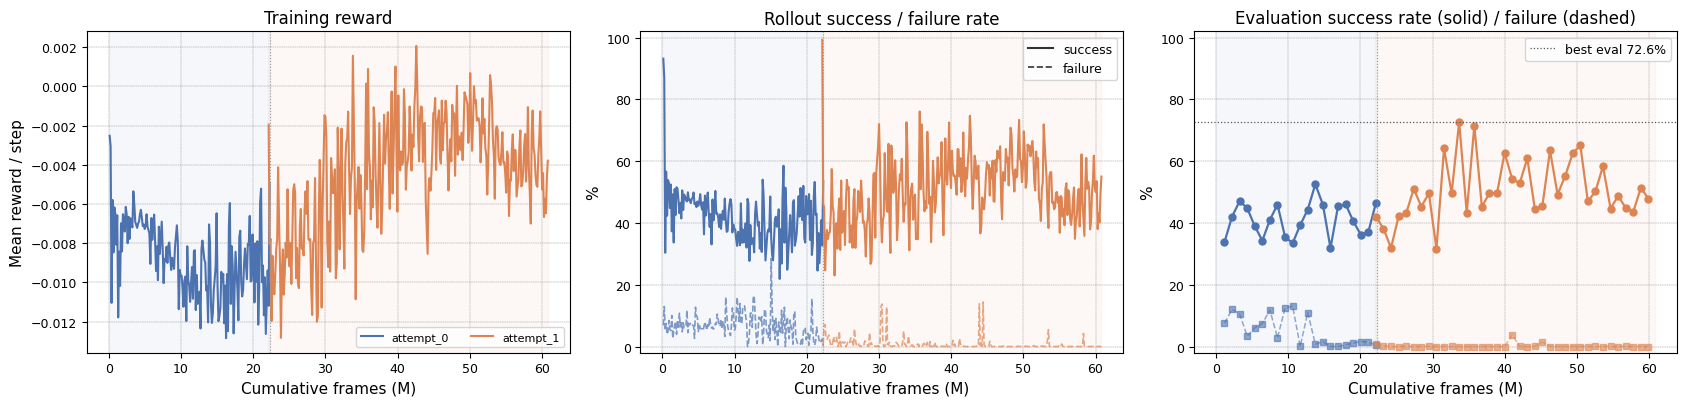

In [183]:
# ── Figure 2: headline learning curves ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 4.2))

# — training reward
ax = axes[0]
if "train" in DATA and "train/mean_reward" in DATA["train"]:
    d = DATA["train"]
    for a, sub in d.groupby("attempt"):
        ax.plot(sub["global_frames"] / 1e6, sub["train/mean_reward"],
                color=ATTEMPT_COLOR[a], linewidth=1.5, label=f"attempt_{a}")
    _mark_attempts(ax)
    ax.legend(fontsize=8, ncol=2)
ax.set_xlabel("Cumulative frames (M)")
ax.set_ylabel("Mean reward / step")
ax.set_title("Training reward")

# — rollout success / failure
ax = axes[1]
if "env" in DATA:
    d = DATA["env"]
    for a, sub in d.groupby("attempt"):
        c = ATTEMPT_COLOR[a]
        if "env/success_rate" in sub:
            ax.plot(sub["global_frames"] / 1e6, 100 * sub["env/success_rate"], color=c, linewidth=1.5)
        if "env/failure_rate" in sub:
            ax.plot(sub["global_frames"] / 1e6, 100 * sub["env/failure_rate"], color=c,
                    linewidth=1.2, linestyle="--", alpha=0.7)
    _mark_attempts(ax)
    ax.plot([], [], color="#333", linewidth=1.5, label="success")
    ax.plot([], [], color="#333", linewidth=1.2, linestyle="--", label="failure")
    ax.legend(fontsize=9)
ax.set_ylim(-2, 102)
ax.set_xlabel("Cumulative frames (M)")
ax.set_ylabel("%")
ax.set_title("Rollout success / failure rate")

# — eval success rate
ax = axes[2]
if "eval" in DATA and "eval/success_rate" in DATA["eval"]:
    d = DATA["eval"]
    for a, sub in d.groupby("attempt"):
        ax.plot(sub["global_frames"] / 1e6, 100 * sub["eval/success_rate"], "o-",
                color=ATTEMPT_COLOR[a], linewidth=1.6, markersize=5)
        if "eval/failure_rate" in sub:
            ax.plot(sub["global_frames"] / 1e6, 100 * sub["eval/failure_rate"], "s--",
                    color=ATTEMPT_COLOR[a], linewidth=1.1, markersize=4, alpha=0.6)
    _mark_attempts(ax)
    best = DATA["eval"]["eval/success_rate"].max()
    ax.axhline(100 * best, color="#555", linewidth=0.9, linestyle=":",
               label=f"best eval {100*best:.1f}%")
    ax.legend(fontsize=9)
else:
    ax.text(0.5, 0.5, "no eval.csv", ha="center", va="center", transform=ax.transAxes)
ax.set_ylim(-2, 102)
ax.set_xlabel("Cumulative frames (M)")
ax.set_ylabel("%")
ax.set_title("Evaluation success rate (solid) / failure (dashed)")

plt.tight_layout()
_savefig("learning_curves")
plt.show()

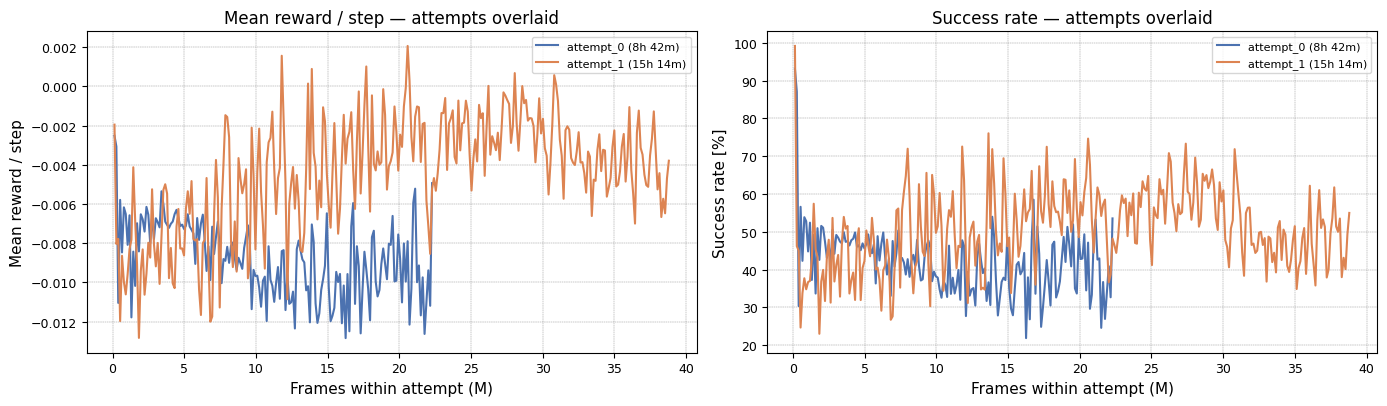

In [184]:
# ── Same curves overlaid per attempt (x = frames within the attempt) ─────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
for ax, (grp, col, lbl) in zip(axes, [("train", "train/mean_reward", "Mean reward / step"),
                                      ("env",   "env/success_rate",  "Success rate")]):
    d = DATA.get(grp)
    if d is None or col not in d:
        ax.axis("off")
        continue
    for a, sub in d.groupby("attempt"):
        y = 100 * sub[col] if "rate" in col else sub[col]
        ax.plot(sub["attempt_frames"] / 1e6, y, color=ATTEMPT_COLOR[a],
                linewidth=1.5, label=f"attempt_{a} ({_fmt_h(attempts.set_index('attempt').loc[a,'hours'])})")
    ax.set_xlabel("Frames within attempt (M)")
    ax.set_ylabel(lbl + (" [%]" if "rate" in col else ""))
    ax.set_title(f"{lbl} — attempts overlaid")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 5  Optimisation diagnostics

Straight from `train.csv`, so this adapts to the trainer: PPO logs losses/entropy/KL/clip-fraction/
grad-norm/LRs, the D3QN family logs epsilon, replay-buffer size, TD loss and Q means, C-TRAC logs its
actor/critic/CVAE losses.

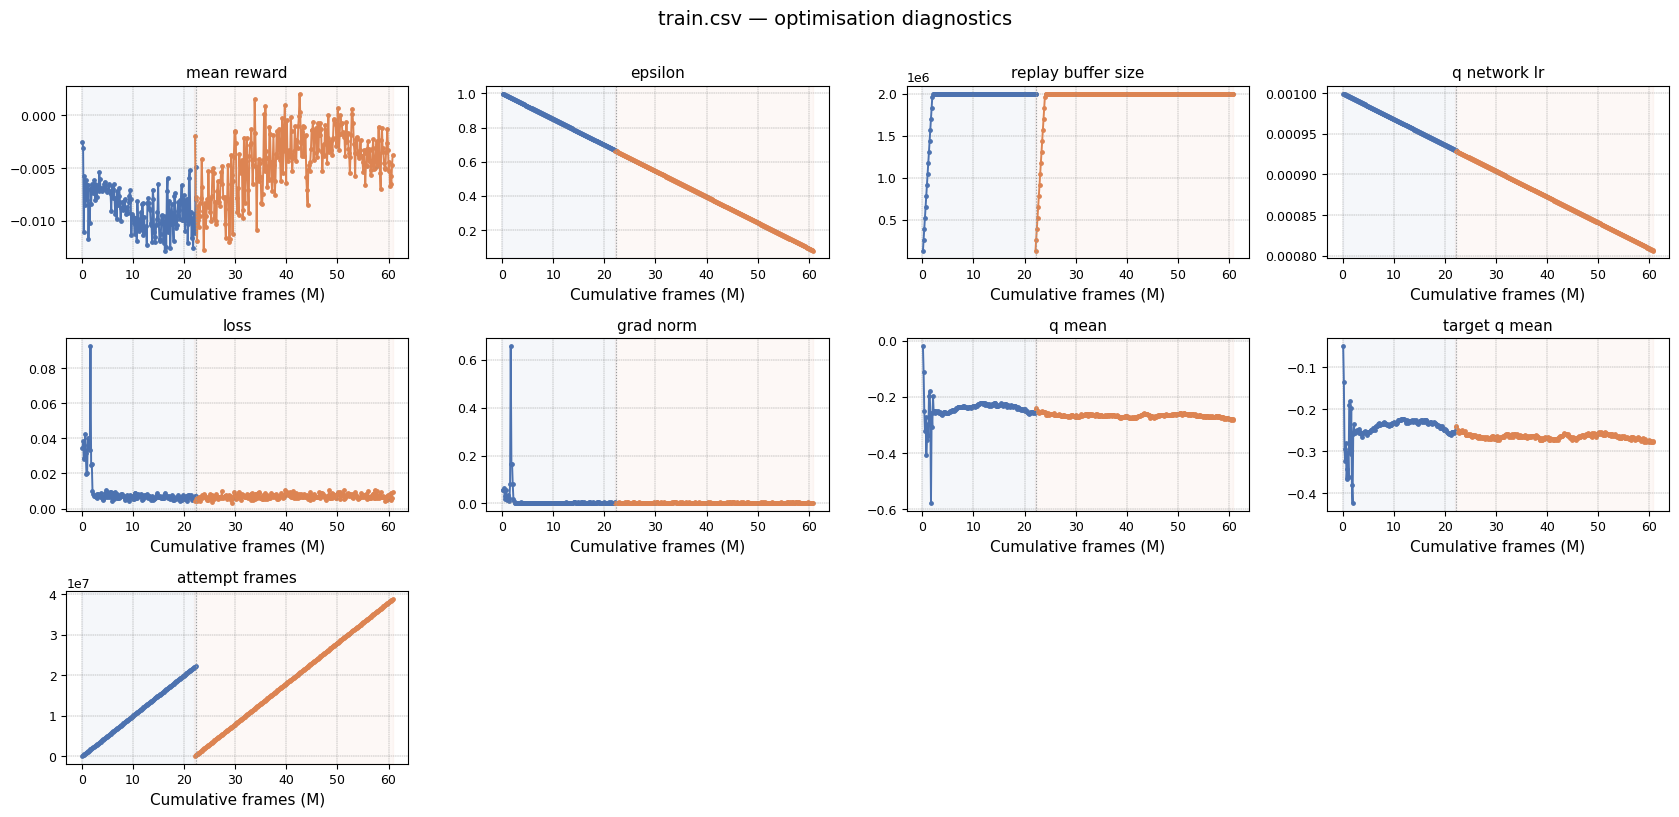

In [185]:
plot_group("train", ncols=4, title="train.csv — optimisation diagnostics")
_savefig("train_diagnostics")
plt.show()

## 6  Reward decomposition

`rew.csv` holds the mean per-step value of each reward component. `grad_contrib.csv` /
`var_decomp.csv` (PPO/grad runs only) attribute gradient magnitude and return variance to those same
components — a term with a large value but negligible variance share is not what is driving learning.

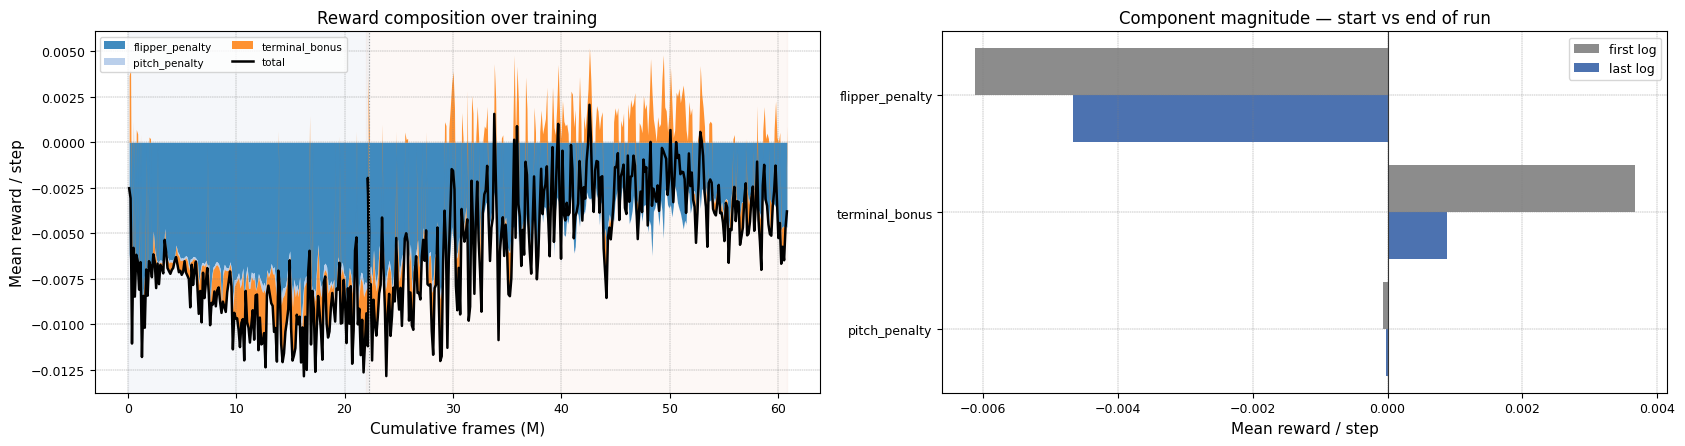

In [186]:
# ── Figure: reward components — stacked contribution + individual traces ──────
d = DATA.get("rew")
if d is None:
    print("[skip] no rew.csv")
else:
    comp_cols = [c for c in d.columns if c.startswith("rew/") and c != "rew/total_reward"]
    x = d["global_frames"] / 1e6

    fig, axes = plt.subplots(1, 2, figsize=(17, 4.6))

    ax = axes[0]
    pos = np.zeros(len(d)); neg = np.zeros(len(d))
    cmap = plt.get_cmap("tab20")
    for i, c in enumerate(comp_cols):
        v = d[c].fillna(0).to_numpy()
        base = np.where(v >= 0, pos, neg)
        ax.fill_between(x, base, base + v, color=cmap(i % 20), alpha=0.85,
                        label=c.split("/", 1)[1], linewidth=0)
        pos = pos + np.clip(v, 0, None)
        neg = neg + np.clip(v, None, 0)
    if "rew/total_reward" in d:
        ax.plot(x, d["rew/total_reward"], color="black", linewidth=1.8, label="total")
    _mark_attempts(ax)
    ax.set_xlabel("Cumulative frames (M)")
    ax.set_ylabel("Mean reward / step")
    ax.set_title("Reward composition over training")
    ax.legend(fontsize=7.5, ncol=2, loc="upper left")

    ax = axes[1]
    last = d.iloc[-1]
    first = d.iloc[0]
    order = np.argsort([abs(last[c]) for c in comp_cols])[::-1]
    names = [comp_cols[i].split("/", 1)[1] for i in order]
    yy = np.arange(len(names))
    ax.barh(yy - 0.2, [first[comp_cols[i]] for i in order], height=0.4,
            color="#8C8C8C", label="first log")
    ax.barh(yy + 0.2, [last[comp_cols[i]] for i in order], height=0.4,
            color="#4C72B0", label="last log")
    ax.set_yticks(yy); ax.set_yticklabels(names)
    ax.invert_yaxis()
    ax.axvline(0, color="#333", linewidth=0.8)
    ax.set_xlabel("Mean reward / step")
    ax.set_title("Component magnitude — start vs end of run")
    ax.legend(fontsize=9)

    plt.tight_layout()
    _savefig("reward_components")
    plt.show()

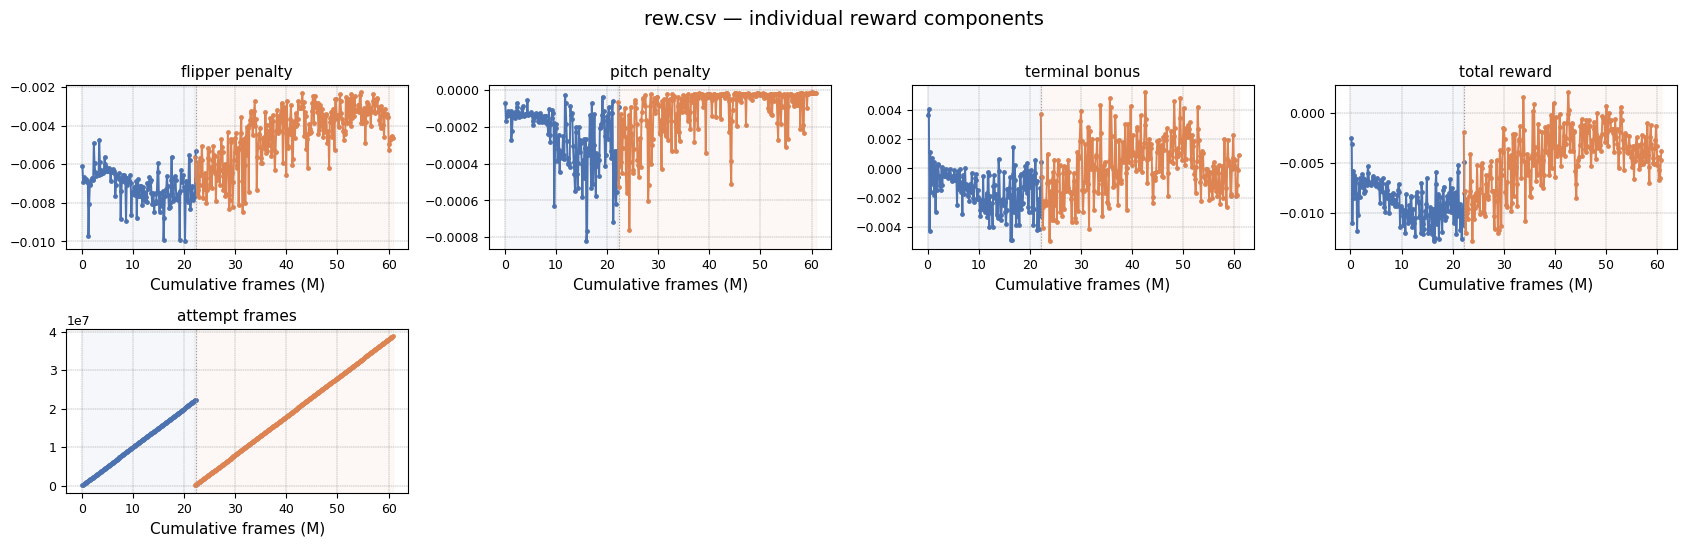

In [187]:
plot_group("rew", ncols=4, title="rew.csv — individual reward components")
plt.show()

In [188]:
# ── Gradient contribution / variance decomposition (share of total, %) ───────
for grp, label in [("grad_contrib", "Gradient contribution"), ("var_decomp", "Return-variance share")]:
    d = DATA.get(grp)
    if d is None:
        print(f"[skip] no {grp}.csv")
        continue
    cols = [c for c in d.columns if c.startswith(f"{grp}/")]
    vals = d[cols].abs()
    share = 100 * vals.div(vals.sum(axis=1).replace(0, np.nan), axis=0)
    x = d["global_frames"] / 1e6

    fig, axes = plt.subplots(1, 2, figsize=(17, 4.2), gridspec_kw={"width_ratios": [2, 1]})
    ax = axes[0]
    ax.stackplot(x, [share[c].fillna(0) for c in cols],
                 labels=[c.split("/", 1)[1] for c in cols],
                 colors=[plt.get_cmap("tab20")(i % 20) for i in range(len(cols))], alpha=0.9)
    _mark_attempts(ax)
    ax.set_xlim(x.min(), x.max())
    ax.set_ylim(0, 100)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_xlabel("Cumulative frames (M)")
    ax.set_title(f"{label} — share of total over training")
    ax.legend(fontsize=7.5, ncol=2, loc="lower left")

    ax = axes[1]
    mean_share = share.mean().sort_values()
    ax.barh([c.split("/", 1)[1] for c in mean_share.index], mean_share.values, color="#4C72B0")
    for i, v in enumerate(mean_share.values):
        ax.text(v, i, f" {v:.1f}%", va="center", fontsize=8.5)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())
    ax.margins(x=0.16)
    ax.set_title(f"Mean {label.lower()}")
    plt.tight_layout()
    _savefig(grp)
    plt.show()

[skip] no grad_contrib.csv
[skip] no var_decomp.csv


## 7  Evaluation

Mid-training eval runs (`eval_and_save_every` iterations) write `eval.csv` and, per terrain row,
`eval_per_env.csv`. Env-type names come straight from the CSV headers, which the trainer derives from
the terrain's `gen_config` — see `training/env_type_registry.py`.

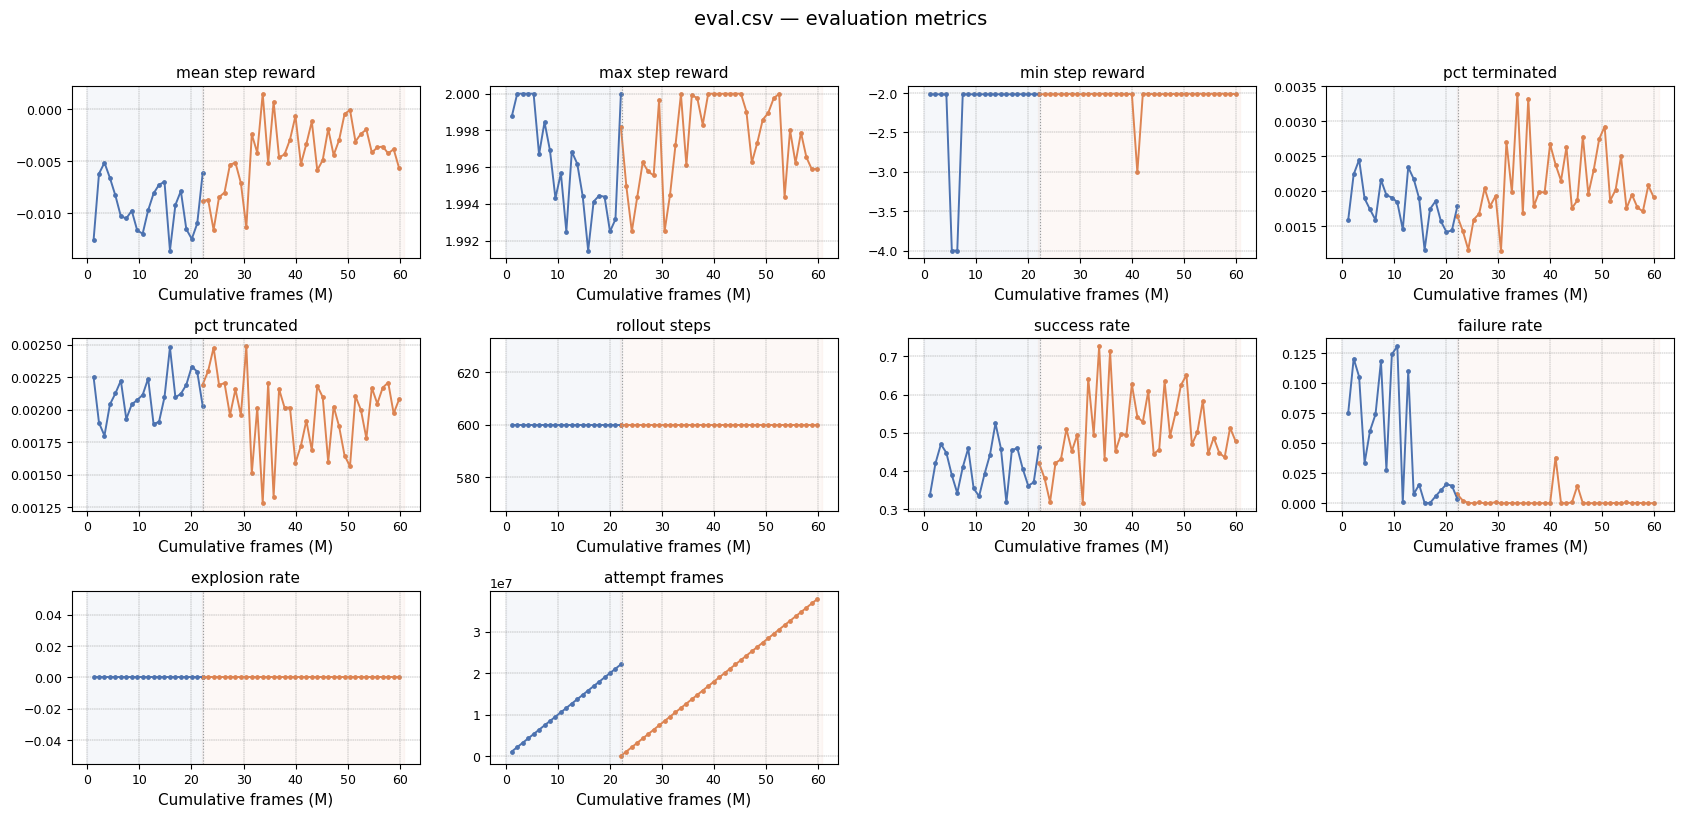

In [189]:
plot_group("eval", ncols=4, title="eval.csv — evaluation metrics")
plt.show()

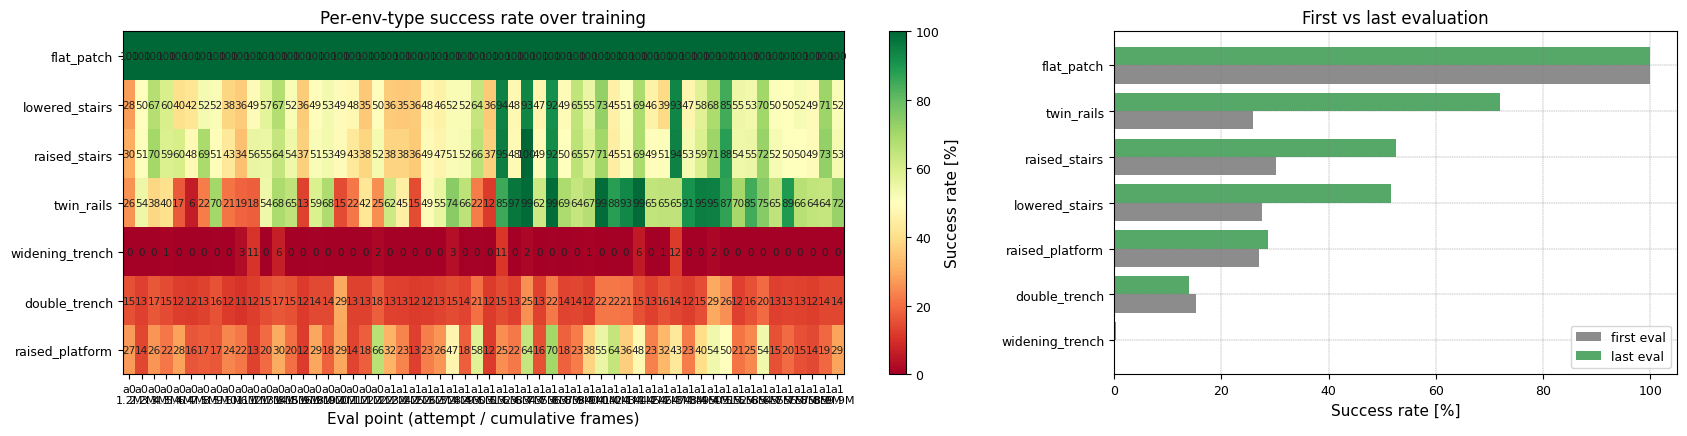

In [190]:
# ── Per-env-type success rate: heatmap over eval points + final bar ──────────
d = DATA.get("eval_per_env")
if d is None:
    print("[skip] no eval_per_env.csv")
else:
    cols = [c for c in d.columns if c.endswith("_success_rate")]
    names = [c.split("/", 1)[1].replace("_success_rate", "") for c in cols]
    M = 100 * d[cols].to_numpy().T                      # env_type x eval point
    xlabels = [f"a{int(a)}\n{f/1e6:.1f}M" for a, f in zip(d["attempt"], d["global_frames"])]

    fig, axes = plt.subplots(1, 2, figsize=(17, max(4.5, 0.34 * len(names) + 2)),
                             gridspec_kw={"width_ratios": [1.6, 1]})
    ax = axes[0]
    im = ax.imshow(M[::-1], aspect="auto", cmap="RdYlGn", vmin=0, vmax=100)
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names[::-1], fontsize=9)
    ax.set_xticks(range(len(xlabels)))
    ax.set_xticklabels(xlabels, fontsize=8)
    ax.set_xlabel("Eval point (attempt / cumulative frames)")
    ax.grid(False)
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            if np.isfinite(M[::-1][i, j]):
                ax.text(j, i, f"{M[::-1][i, j]:.0f}", ha="center", va="center", fontsize=7.5,
                        color="#222")
    plt.colorbar(im, ax=ax, label="Success rate [%]")
    ax.set_title("Per-env-type success rate over training")

    ax = axes[1]
    first_v, last_v = 100 * d[cols].iloc[0].to_numpy(), 100 * d[cols].iloc[-1].to_numpy()
    order = np.argsort(last_v)
    yy = np.arange(len(names))
    ax.barh(yy - 0.2, first_v[order], height=0.4, color="#8C8C8C", label="first eval")
    ax.barh(yy + 0.2, last_v[order], height=0.4, color="#55A868", label="last eval")
    ax.set_yticks(yy)
    ax.set_yticklabels([names[i] for i in order], fontsize=9)
    ax.set_xlim(0, 105)
    ax.set_xlabel("Success rate [%]")
    ax.set_title("First vs last evaluation")
    ax.legend(fontsize=9, loc="lower right")
    plt.tight_layout()
    _savefig("eval_per_env")
    plt.show()

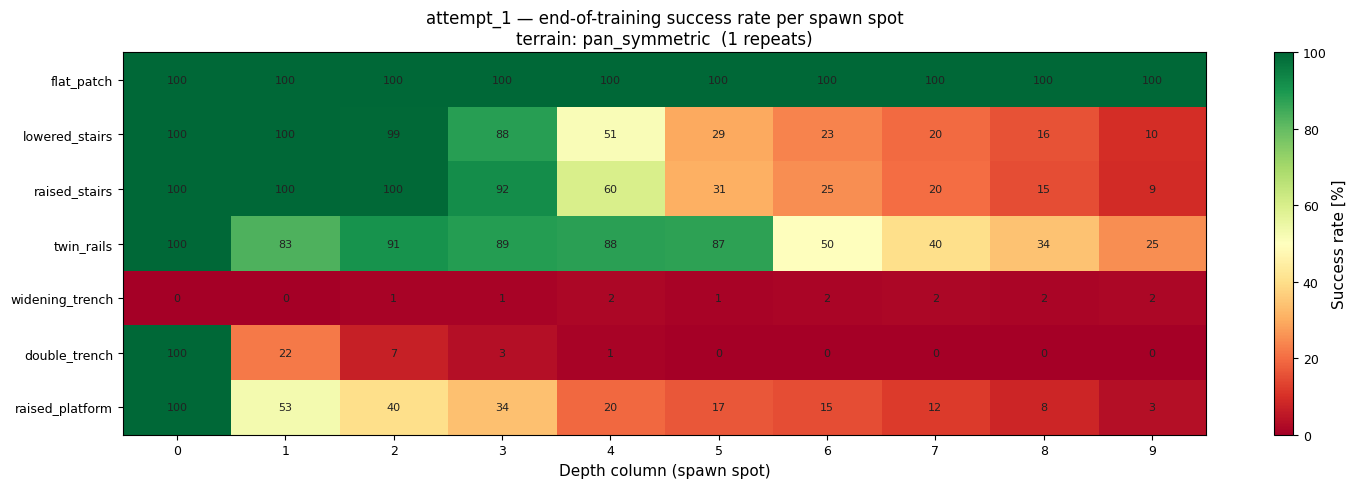

In [191]:
# ── End-of-training per-spot eval (env type x depth column), last attempt ────
_spot_files = [(a, d / "eval_per_spot.csv") for a, d in zip(attempts["attempt"], attempts["dir"])]
_spot_files = [(a, p) for a, p in _spot_files if p.exists()]
if not _spot_files:
    print("[skip] no eval_per_spot.csv in any attempt")
else:
    a, p = _spot_files[-1]
    sp = pd.read_csv(p)
    piv = (sp.groupby(["env_type_idx", "env_type_name", "depth_col"])["success_rate"]
             .mean().reset_index())
    M = piv.pivot(index="env_type_idx", columns="depth_col", values="success_rate") * 100
    row_names = (piv.drop_duplicates("env_type_idx").set_index("env_type_idx")["env_type_name"]
                    .reindex(M.index).tolist())

    fig, ax = plt.subplots(figsize=(1.0 * M.shape[1] + 5, 0.36 * M.shape[0] + 2.5))
    im = ax.imshow(M.to_numpy()[::-1], aspect="auto", cmap="RdYlGn", vmin=0, vmax=100)
    ax.set_yticks(range(len(row_names)))
    ax.set_yticklabels(row_names[::-1], fontsize=9)
    ax.set_xticks(range(M.shape[1]))
    ax.set_xticklabels(M.columns, fontsize=9)
    ax.set_xlabel("Depth column (spawn spot)")
    ax.grid(False)
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            v = M.to_numpy()[::-1][i, j]
            if np.isfinite(v):
                ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=8, color="#222")
    plt.colorbar(im, ax=ax, label="Success rate [%]")
    ax.set_title(f"attempt_{a} — end-of-training success rate per spawn spot\n"
                 f"terrain: {sp['terrain'].iloc[0] if 'terrain' in sp else '?'}  "
                 f"({sp['repeat'].nunique()} repeats)")
    plt.tight_layout()
    _savefig("eval_per_spot")
    plt.show()

## 8  Failures, explosions and physics health

`failure.csv` splits terminations by cause; `explosion(s).csv` tracks physics blow-ups — NaN/huge
states detected pre- and post-step — and how many optimisation updates were skipped because the batch
was contaminated. A rising `explosions/skipped_updates_frac` means the trainer is throwing away real
work, and is the usual precursor of the CUDA illegal-memory-access crash that ends these jobs.

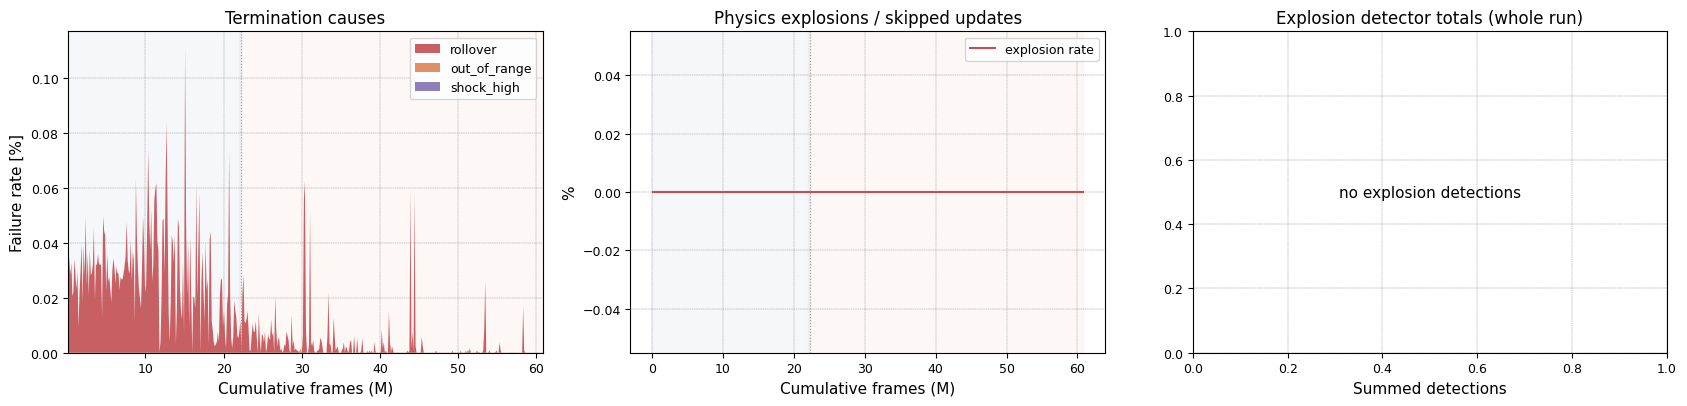

In [192]:
# ── Figure: failure causes + explosion rate ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 4.2))

ax = axes[0]
d = DATA.get("failure")
if d is not None:
    cols = [c for c in d.columns if c.startswith("failure/")]
    x = d["global_frames"] / 1e6
    ax.stackplot(x, [100 * d[c].fillna(0) for c in cols],
                 labels=[c.split("/", 1)[1] for c in cols],
                 colors=["#C44E52", "#DD8452", "#8172B3", "#937860"][:len(cols)], alpha=0.9)
    _mark_attempts(ax)
    ax.set_xlim(x.min(), x.max())
    ax.legend(fontsize=9)
ax.set_xlabel("Cumulative frames (M)")
ax.set_ylabel("Failure rate [%]")
ax.set_title("Termination causes")

ax = axes[1]
d = DATA.get("explosions")
if d is not None:
    x = d["global_frames"] / 1e6
    if "explosions/rate" in d:
        ax.plot(x, 100 * d["explosions/rate"], color="#C44E52", linewidth=1.5, label="explosion rate")
    if "explosions/skipped_updates_frac" in d:
        ax.plot(x, 100 * d["explosions/skipped_updates_frac"], color="#4C72B0",
                linewidth=1.5, label="skipped updates")
    _mark_attempts(ax)
    ax.legend(fontsize=9)
elif DATA.get("explosion") is not None and "explosion/pct_exploded" in DATA["explosion"]:
    d = DATA["explosion"]
    ax.plot(d["global_frames"] / 1e6, d["explosion/pct_exploded"], color="#C44E52", linewidth=1.5)
    _mark_attempts(ax)
ax.set_xlabel("Cumulative frames (M)")
ax.set_ylabel("%")
ax.set_title("Physics explosions / skipped updates")

ax = axes[2]
d = DATA.get("explosion")
if d is not None:
    cols = [c for c in d.columns if c.startswith("explosion/") and c != "explosion/pct_exploded"]
    tot = d[cols].sum().sort_values()
    tot = tot[tot > 0]
    if len(tot):
        ax.barh([c.split("/", 1)[1] for c in tot.index], tot.values, color="#C44E52")
        for i, v in enumerate(tot.values):
            ax.text(v, i, f" {v:.3g}", va="center", fontsize=8.5)
        ax.margins(x=0.2)
    else:
        ax.text(0.5, 0.5, "no explosion detections", ha="center", va="center", transform=ax.transAxes)
ax.set_title("Explosion detector totals (whole run)")
ax.set_xlabel("Summed detections")

plt.tight_layout()
_savefig("failures")
plt.show()

## 9  Behaviour — state, actions, contact loads

What the policy is actually doing: body velocities and attitude (`state.csv`), commanded velocity and
the four flipper angles (`action.csv`), shock/acceleration (`shock.csv`), flipper torques
(`torque.csv`) and belly clearance (`clearance.csv`).

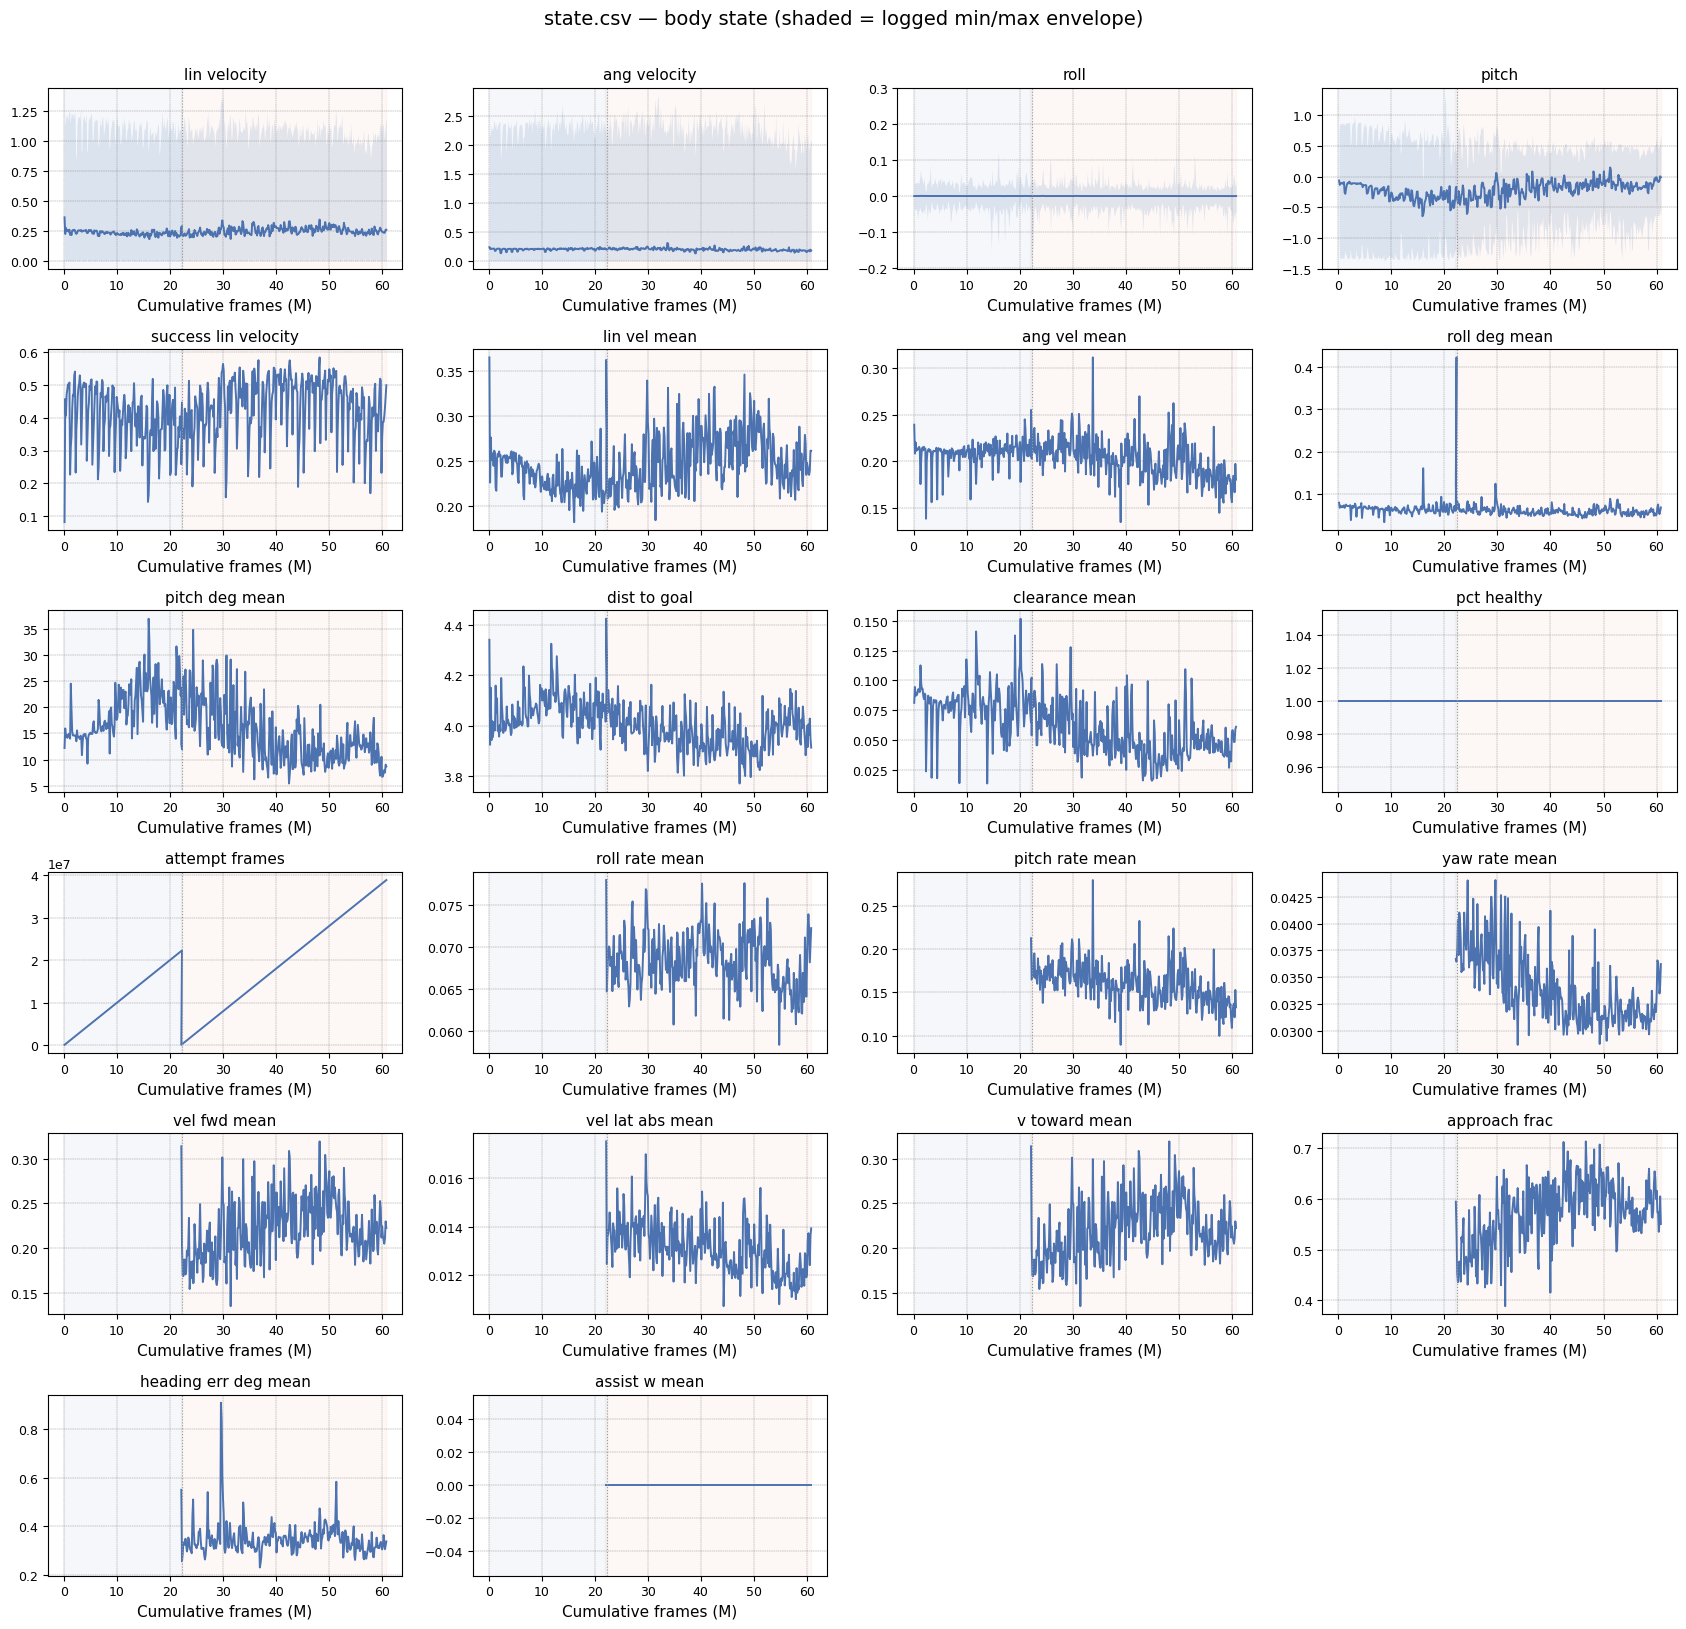

In [193]:
# ── Figure: state summary (mean with min/max envelope where logged) ──────────
d = DATA.get("state")
if d is None:
    print("[skip] no state.csv")
else:
    trios = []
    for c in d.columns:
        if c.endswith("_max") or c.endswith("_min") or c in ("collected_frames", "global_frames", "attempt"):
            continue
        trios.append((c, f"{c}_max" if f"{c}_max" in d else None, f"{c}_min" if f"{c}_min" in d else None))
    trios = [t for t in trios if d[t[0]].notna().any()]
    ncols = 4
    nrows = int(np.ceil(len(trios) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(17, 2.7 * nrows), squeeze=False)
    x = d["global_frames"] / 1e6
    for ax, (m, hi, lo) in zip(axes.ravel(), trios):
        if hi and lo:
            ax.fill_between(x, d[lo], d[hi], color="#4C72B0", alpha=0.15, linewidth=0)
        ax.plot(x, d[m], color="#4C72B0", linewidth=1.4)
        _mark_attempts(ax)
        ax.set_title(m.split("/", 1)[-1].replace("_", " "), fontsize=11)
        ax.set_xlabel("Cumulative frames (M)")
    for ax in axes.ravel()[len(trios):]:
        ax.axis("off")
    fig.suptitle("state.csv — body state (shaded = logged min/max envelope)", y=1.004)
    plt.tight_layout()
    _savefig("state")
    plt.show()

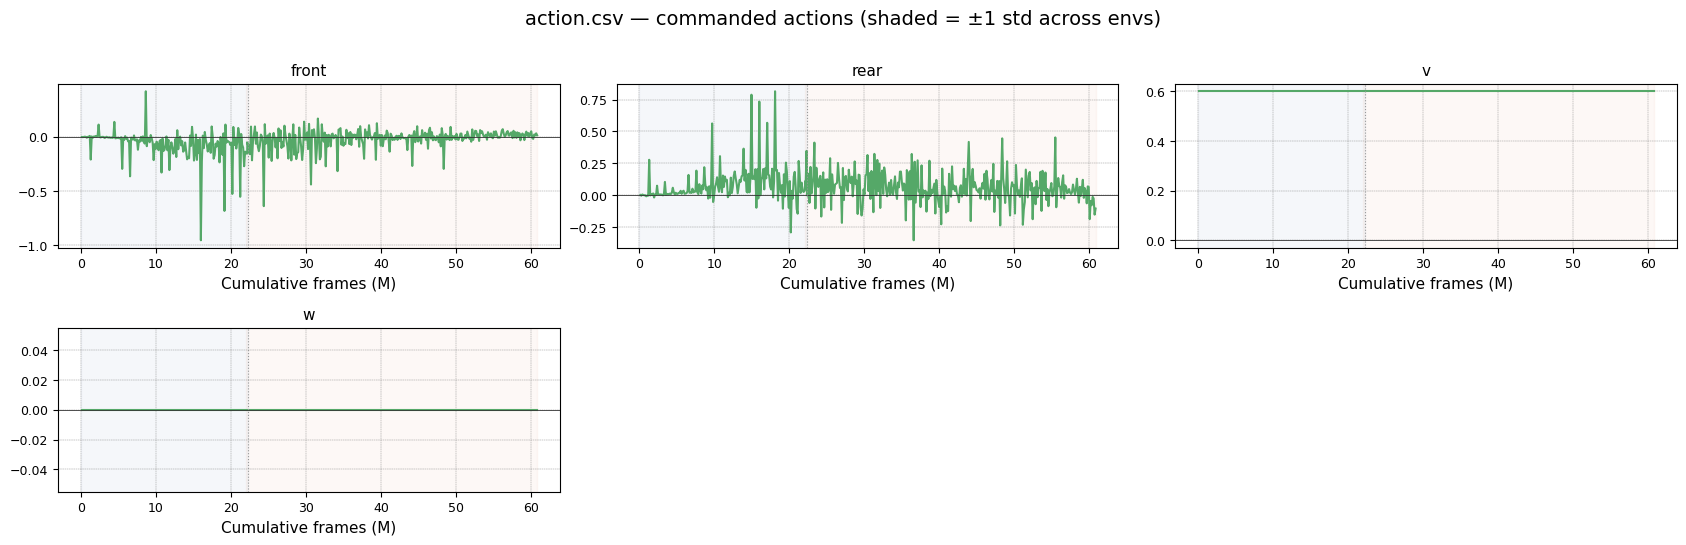

In [194]:
# ── Figure: actions — mean ± std per action dimension ────────────────────────
d = DATA.get("action")
if d is None:
    print("[skip] no action.csv")
else:
    dims = sorted({c.split("/", 1)[1].rsplit("_", 1)[0] for c in d.columns if c.startswith("action/")})
    ncols = 3
    nrows = int(np.ceil(len(dims) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(17, 2.7 * nrows), squeeze=False)
    x = d["global_frames"] / 1e6
    for ax, dim in zip(axes.ravel(), dims):
        mcol, scol = f"action/{dim}_mean", f"action/{dim}_std"
        if mcol not in d:
            ax.axis("off"); continue
        mu = d[mcol]
        ax.plot(x, mu, color="#55A868", linewidth=1.5)
        if scol in d:
            ax.fill_between(x, mu - d[scol], mu + d[scol], color="#55A868", alpha=0.18, linewidth=0)
        ax.axhline(0, color="#333", linewidth=0.6)
        _mark_attempts(ax)
        ax.set_title(dim.replace("_", " "), fontsize=11)
        ax.set_xlabel("Cumulative frames (M)")
    for ax in axes.ravel()[len(dims):]:
        ax.axis("off")
    fig.suptitle("action.csv — commanded actions (shaded = ±1 std across envs)", y=1.004)
    plt.tight_layout()
    _savefig("actions")
    plt.show()

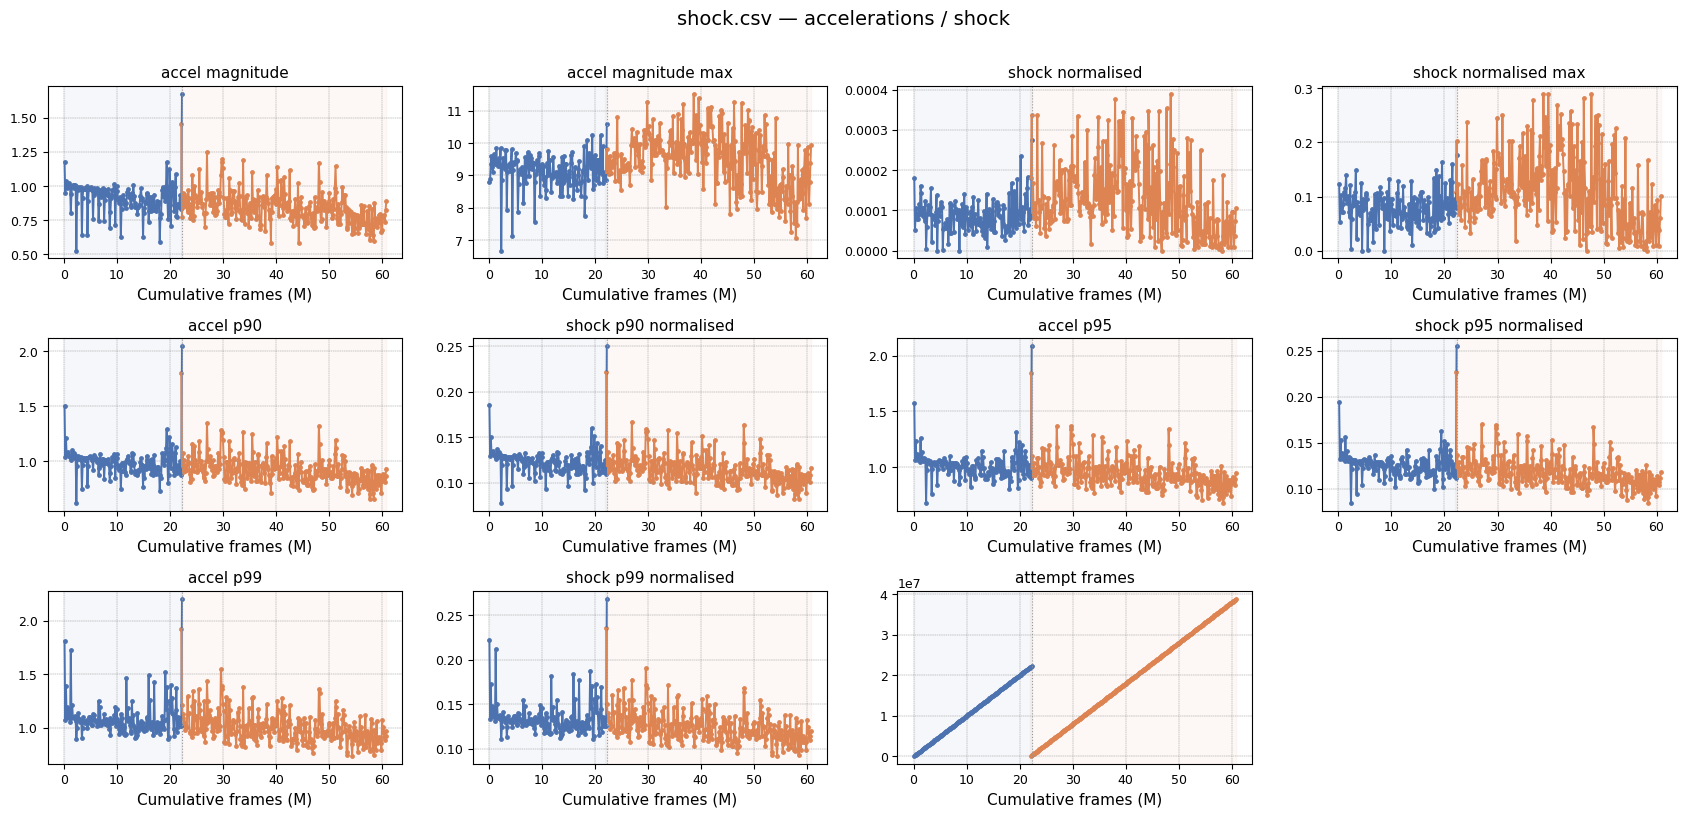

In [195]:
plot_group("shock", ncols=4, exclude=("_min",), title="shock.csv — accelerations / shock")
plt.show()

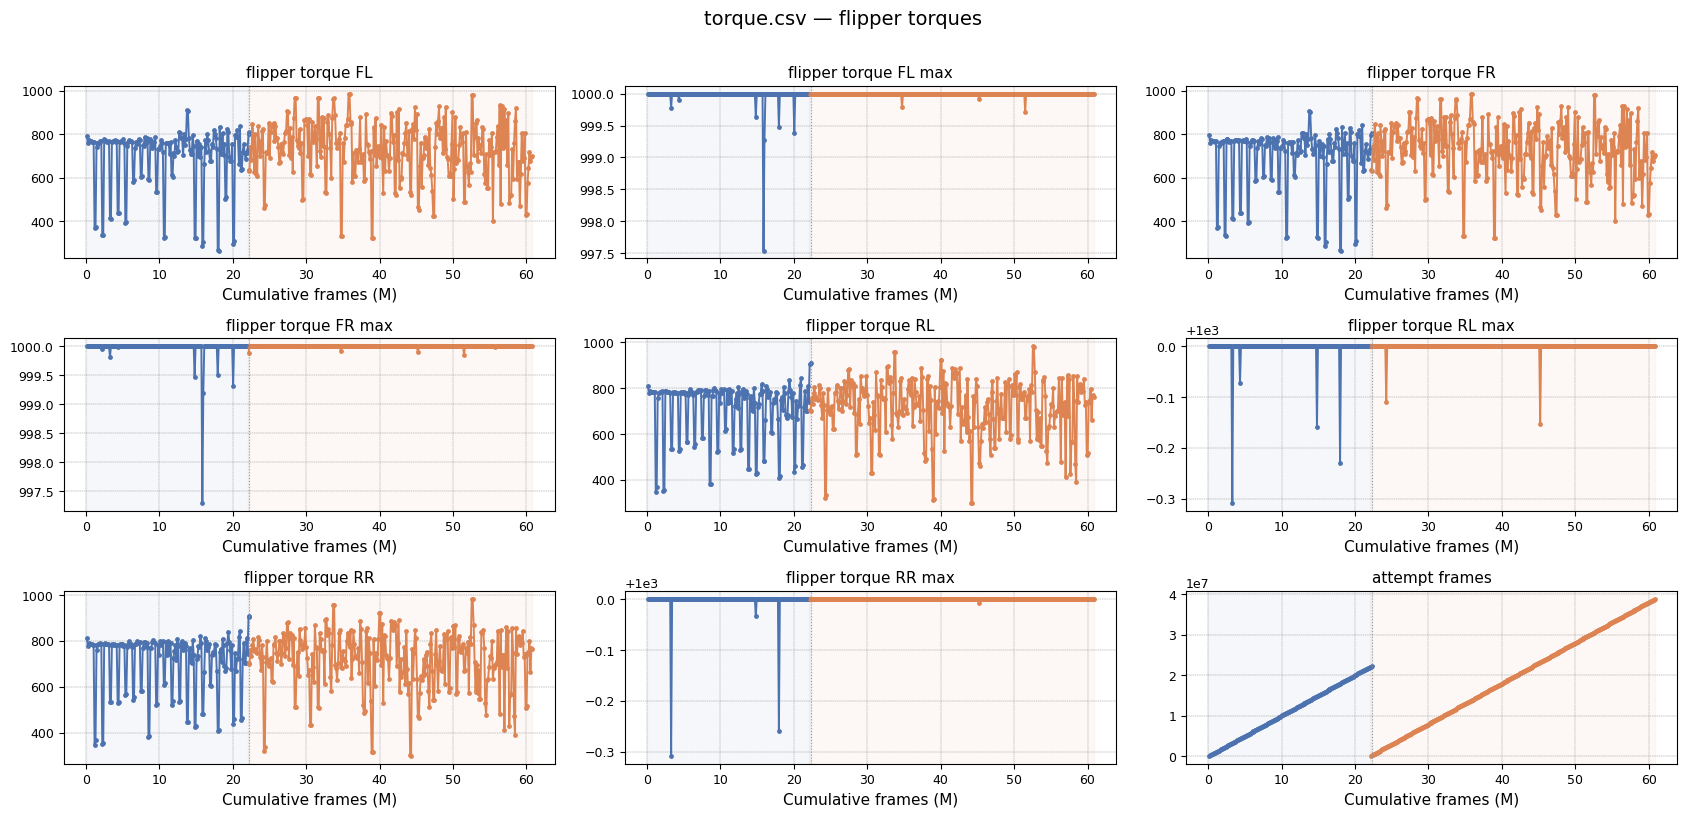

In [196]:
plot_group("torque", ncols=3, exclude=("_min",), title="torque.csv — flipper torques")
plt.show()

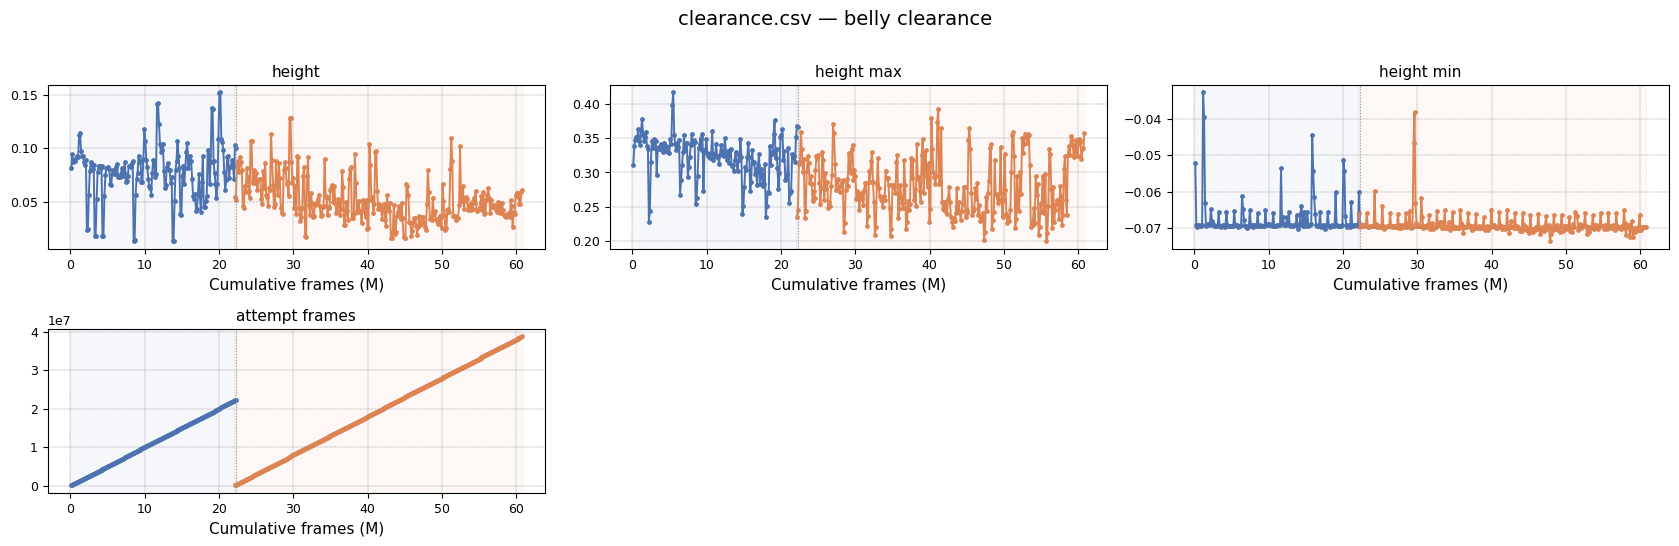

In [197]:
plot_group("clearance", ncols=3, title="clearance.csv — belly clearance")
plt.show()

## 10  Attempt outcome audit

Why each attempt ended, and what the crash cycle cost — the per-run counterpart of
`slurm_trial_audit.ipynb`, which does this across whole jobs. Statuses are read off the `.out`:
`Training failed: …` gives the Python-side cause, `Python script finished with exit status: N` the
container exit code (75 = CUDA/W&B error and triggers a respawn, 255 = container killed).

,attempt,outcome,exit_status,hours,frames,lost_frames,fail_msg
0,0,Crash — CUDA error,75.000000,8.70,"22,282,240","131,072",CUDA error: an illegal memory access was encountered
1,1,Still running / killed,nan,15.24,"38,797,312",0,


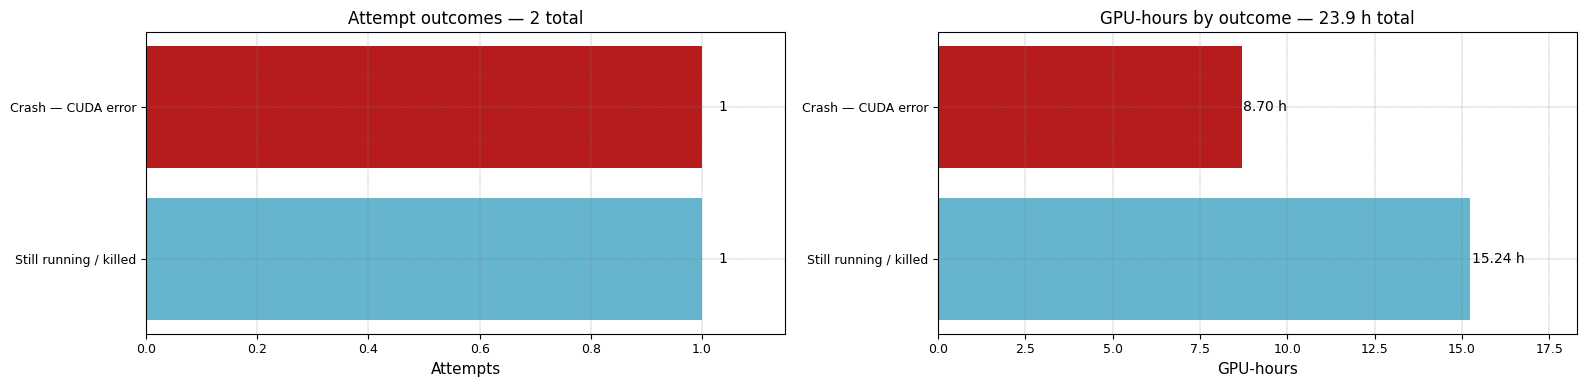

GPU-hours spent on frames discarded by crashes : 0.05 h (0.2% of training time)
Startup + respawn overhead                     : 0.00 h (0.0% of job span)


In [198]:
STATUS_LABELS = {
    "success":                    "Success",
    "crash_cuda":                 "Crash — CUDA error",
    "crash_oom":                  "Crash — out of memory",
    "crash_python":               "Crash — Python exception",
    "crash_75_cuda_or_wandb":     "Crash — exit 75 (CUDA / W&B, respawned)",
    "crash_255_container_killed": "Crash — exit 255 (container killed)",
    "exit0_with_error":           "Exit 0 but error logged",
    "timeout":                    "SLURM timeout",
    "cancelled":                  "SLURM cancelled",
    "killed_no_exit":             "Killed (no exit status)",
    "running_or_killed":          "Still running / killed",
    "unknown":                    "Unknown (no log segment)",
}
STATUS_COLORS = {
    "success": "#55A868", "crash_cuda": "#b71c1c", "crash_oom": "#e91e63",
    "crash_python": "#C44E52", "crash_75_cuda_or_wandb": "#DD8452",
    "crash_255_container_killed": "#8172B3", "exit0_with_error": "#CCB974",
    "timeout": "#9c27b0", "cancelled": "#8C8C8C", "killed_no_exit": "#795548",
    "running_or_killed": "#64B5CD", "unknown": "#B0B0B0",
}

audit = attempts[["attempt", "hours", "frames", "lost_frames", "exit_status",
                  "status", "fail_msg", "exceptions"]].copy()
audit["outcome"] = audit["status"].map(lambda s: STATUS_LABELS.get(s, s))
audit["fail_msg"] = audit["fail_msg"].fillna("").str.slice(0, 90)
display(audit[["attempt", "outcome", "exit_status", "hours", "frames", "lost_frames", "fail_msg"]]
        .style.format({"hours": "{:.2f}", "frames": "{:,.0f}", "lost_frames": "{:,.0f}"}))

by_status = (attempts.groupby("status")
             .agg(count=("status", "count"), hours=("hours", "sum"),
                  frames=("frames", "sum"), lost=("lost_frames", "sum"))
             .reset_index().sort_values("count", ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 4.0))
ax = axes[0]
labels = [STATUS_LABELS.get(s, s) for s in by_status["status"]]
colors = [STATUS_COLORS.get(s, "#90a4ae") for s in by_status["status"]]
bars = ax.barh(labels[::-1], by_status["count"].values[::-1], color=colors[::-1])
for bar, v in zip(bars, by_status["count"].values[::-1]):
    ax.text(bar.get_width() + 0.03, bar.get_y() + bar.get_height() / 2, str(int(v)),
            va="center", fontsize=10)
ax.margins(x=0.15)
ax.set_xlabel("Attempts")
ax.set_title(f"Attempt outcomes — {len(attempts)} total")

ax = axes[1]
bars = ax.barh(labels[::-1], by_status["hours"].values[::-1], color=colors[::-1])
for bar, v in zip(bars, by_status["hours"].values[::-1]):
    ax.text(bar.get_width() + 0.03, bar.get_y() + bar.get_height() / 2, f"{v:.2f} h",
            va="center", fontsize=10)
ax.margins(x=0.2)
ax.set_xlabel("GPU-hours")
ax.set_title(f"GPU-hours by outcome — {total_hours:.1f} h total")
plt.tight_layout()
_savefig("attempt_outcomes")
plt.show()

_lost_h = (attempts["lost_frames"] / attempts["frames"].replace(0, np.nan) * attempts["hours"]).sum()
print(f"GPU-hours spent on frames discarded by crashes : {_lost_h:.2f} h "
      f"({100*_lost_h/max(total_hours,1e-9):.1f}% of training time)")
print(f"Startup + respawn overhead                     : {max(overhead_h,0):.2f} h "
      f"({100*max(overhead_h,0)/max(job_span_h,1e-9):.1f}% of job span)")

train_atd3qn_11396783.err  —  1,077 lines

Error signatures:


,count
signature,
GPU foundation error,4
CUDA illegal memory access,3
SLURM cancel signal,2
PhysX error,1
srun error,1


Python exception types seen:


,count
exception,
RuntimeError,1


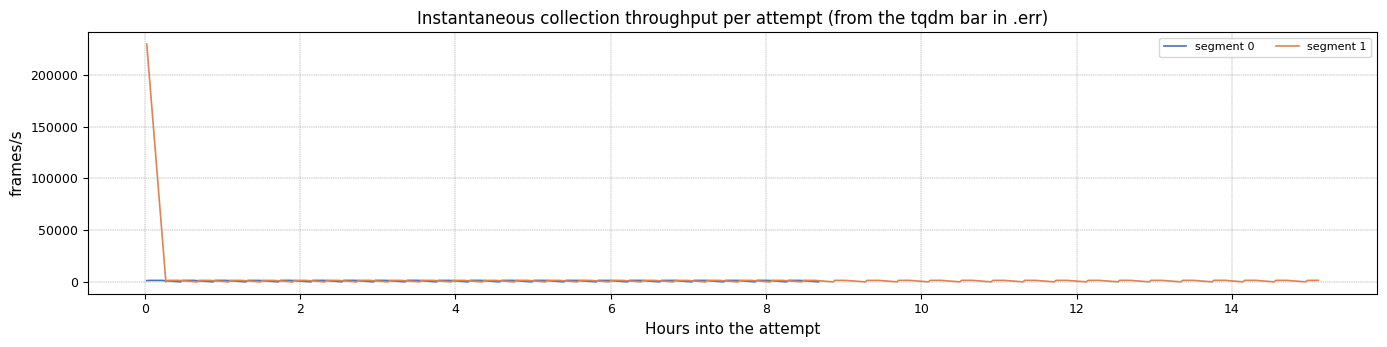

In [199]:
# ── Error signatures in the job's stderr ─────────────────────────────────────
if ERR_PATH is None:
    print("[skip] no .err file")
else:
    err_text = ERR_PATH.read_text(errors="replace")
    from collections import Counter
    sigs = Counter()
    for pat, name in [
        (r"CUDA error: an illegal memory access was encountered", "CUDA illegal memory access"),
        (r"CUDA out of memory",                                    "CUDA out of memory"),
        (r"\[Error\] \[omni\.physx",                               "PhysX error"),
        (r"\[Error\] \[gpu\.foundation\.plugin\]",                 "GPU foundation error"),
        (r"srun: error",                                           "srun error"),
        (r"CANCELLED AT",                                          "SLURM cancel signal"),
    ]:
        n = len(re.findall(pat, err_text))
        if n:
            sigs[name] = n
    exc = Counter(_RE_EXC_TYPE.findall(err_text))

    print(f"{ERR_PATH.name}  —  {len(err_text.splitlines()):,} lines\n")
    if sigs:
        print("Error signatures:")
        display(pd.DataFrame(sigs.most_common(), columns=["signature", "count"]).set_index("signature"))
    if exc:
        print("Python exception types seen:")
        display(pd.DataFrame(exc.most_common(15), columns=["exception", "count"]).set_index("exception"))

    # tqdm throughput: instantaneous frames/s over the whole job, split where the bar resets
    tq = [(int(a), (int(h) if h else 0) * 3600 + int(mi) * 60 + int(s))
          for a, _, h, mi, s in _RE_TQDM.findall(err_text)]
    if len(tq) > 4:
        seg, segs_tq = [], []
        prev = -1
        for frames, elapsed in tq:
            if elapsed < prev:
                segs_tq.append(seg); seg = []
            seg.append((frames, elapsed)); prev = elapsed
        segs_tq.append(seg)
        fig, ax = plt.subplots(figsize=(14, 3.6))
        for i, s in enumerate(segs_tq):
            if len(s) < 3:
                continue
            # tqdm reprints the same frame count several times per iteration; keep only the lines
            # where the counter actually moved, so the rate is per iteration and not a sawtooth
            f = np.array([p[0] for p in s], dtype=float)
            t = np.array([p[1] for p in s], dtype=float)
            keep = np.r_[True, np.diff(f) > 0]
            f, t = f[keep], t[keep]
            if len(f) < 3:
                continue
            dt_ = np.diff(t)
            ok = dt_ > 0
            ax.plot(t[1:][ok] / 3600, np.diff(f)[ok] / dt_[ok],
                    linewidth=1.2, color=ATTEMPT_PALETTE[i % len(ATTEMPT_PALETTE)],
                    label=f"segment {i}")
        ax.set_xlabel("Hours into the attempt")
        ax.set_ylabel("frames/s")
        ax.set_title("Instantaneous collection throughput per attempt (from the tqdm bar in .err)")
        ax.legend(fontsize=8, ncol=3)
        plt.tight_layout()
        _savefig("throughput")
        plt.show()

## 11  Free-form exploration

`DATA[<group>]` holds every CSV concatenated across attempts with `attempt` and `global_frames`
columns added; `RAW[attempt][<group>]` is the untouched per-attempt frame. `plot_group("<group>")`
draws a panel per metric — pass `per_attempt=True` to overlay attempts on the within-attempt frame
axis, `smooth=N` to rolling-mean, `cols=[...]` to pick specific metrics.

In [200]:
# Examples — edit freely.
# plot_group("observations", ncols=4, exclude=("_min", "_max")); plt.show()
# plot_group("train", cols=["train/mean_reward", "train/mean_entropy"], per_attempt=True, ncols=2); plt.show()
print("groups:", ", ".join(DATA))

groups: train, env, rew, eval, eval_per_env, failure, explosion, explosions, state, action, shock, torque, clearance
